<a href="https://colab.research.google.com/github/KErarslan/Kriging-Prior-Residual-Learning-PINN-for-Coal-Seam-Thickness-Estimation/blob/main/kriging_vs_pinn_github_pipeline_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Site Name Withheld] Coal Deposit — Kriging vs PINN: Rebuilt-From-Scratch, SCIE (Q2-Q4)-Targeted Robust Pipeline

This notebook replaces two earlier notebooks (exploratory + first hardening pass) with a
clean, from-scratch working sheet. Scope decision:

**In scope:**
- Seed control + checkpointed multi-run execution (to measure and report random-initialization noise)
- Fold-wise (leakage-free) normalization
- **Variogram model selection on the Kriging side** (fair choice among spherical/exponential/gaussian)
- **Capacity ablation on the PINN side** (small/medium/large architecture — evidence for "why this size")
- **Uncertainty calibration** (Kriging variance vs. PINN ensemble spread — which one is more
  consistent with the actual error?)
- Paired Wilcoxon significance testing

**Out of scope (deliberately, judged disproportionate for the SCIE Q2-Q4 target):**
- Co-Kriging / Linear Model of Coregionalization (multivariate, PSD-constrained joint modeling).
  pykrige has no built-in support; writing our own PSD-guaranteed Goulard-Voltz implementation
  would mean adding a new mathematical component that itself needs validation. This will be
  stated as an explicit, one-sentence scope limitation in the manuscript.

Dataset note: an updated version, cross-checked by a collaborator (Micromine) and containing
1-2 corrections, was expected at one point (n<191). This notebook contains no size-dependent
hardcoded values (`len(df)` is used throughout) — it runs unchanged if the input file is updated.


## 1. Setup

In [1]:
!pip install -q pykrige

import os, json, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import wilcoxon, spearmanr
from pykrige.ok import OrdinaryKriging
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# --- PERSISTENT RESULTS FOLDER (CRITICAL) ---
# Colab's local disk ('/content/...') is NOT persistent: when the session disconnects and the VM is
# recycled (unavoidable for long/disconnected jobs), EVERYTHING on disk
# is deleted -- including the checkpoint file. That is why results are written
# to Google Drive; Drive persists independently of the session.
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    RESULTS_DIR = '/content/drive/MyDrive/kriging_vs_pinn_results'
    print('Google Drive mounted. Results will be written to:', RESULTS_DIR)
except ImportError:
    RESULTS_DIR = 'results'   # non-Colab environment (e.g. local Jupyter) -- a local folder is sufficient
    print('Not a Colab environment, using local folder:', RESULTS_DIR)

os.makedirs(RESULTS_DIR, exist_ok=True)
print('Results folder for this run:', RESULTS_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.6 MB/s eta 0:00:00
Device: cpu
Mounted at /content/drive
Google Drive mounted. Results will be written to: /content/drive/MyDrive/kriging_vs_pinn_results
Results folder for this run: /content/drive/MyDrive/kriging_vs_pinn_results


### Practical note for long runs

The `large` architecture takes ~110-120 minutes per seed under full LOOCV (early stopping
rarely triggers for this architecture -- the model genuinely uses most of its 2000-epoch
budget). 14 additional seeds in a single sitting means ~26-27 hours; keeping a Colab
tab/VM uninterrupted for that long is not realistic.

**Recommendation: run `final_seeds` in batches, not all at once** (e.g., 3-4 seeds per
session). Since the checkpoint now lives on Google Drive, even if the session disconnects
and you reconnect -- rerunning the notebook from the top resumes exactly where it left
off, with no progress lost. Completing the work across several short sessions is far more
reliable than attempting it in one continuous run.


## 2. CONFIG

In [2]:
CONFIG = {
    'data_path': 'coal_seam_data.xlsx',

    # --- Kriging: variogram + trend + anisotropy (staged automatic search) ---
    'kriging_variogram_candidates': ['spherical', 'exponential', 'gaussian'],
    'kriging_drift_candidates': [None, ('regional_linear',)],
    'aniso_angles': [0, 45, 90, 135],
    'aniso_scalings': [1.0, 2.0, 3.0, 4.0],
    'kriging_nlags': 15,

    # --- PINN training hyperparameters (fixed across all architectures -> fair ablation) ---
    'lr': 1e-4,
    'lambda_spatial': 0.001,
    'sched_factor': 0.3,
    'sched_patience': 30,
    'epochs': 2000,
    'early_stop_patience': 300,   # cut the fold short if no improvement for this many epochs
    'early_stop_min_delta': 1e-5,

    # --- PINN capacity ablation: candidates ---
    'architectures': {
        'small':  {'n_hidden': 32,  'n_layers': 2},
        'medium': {'n_hidden': 64,  'n_layers': 3},
        'large':  {'n_hidden': 256, 'n_layers': 4},
    },
    # Seed count for the ablation stage (3 architectures x this many seeds x full LOOCV -> expensive,
    # deliberately kept low). Once the winning architecture is determined, additional seeds
    # (below, 'final_seeds') move to a more robust estimate.
    'ablation_seeds': list(range(6)),
    'final_seeds': list(range(20)),   # extended seed list for the winning architecture

    'n_folds': None,   # None = full LOOCV. Set e.g. 20 for a quick trial.
}
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))


{
  "data_path": "coal_seam_data.xlsx",
  "kriging_variogram_candidates": [
    "spherical",
    "exponential",
    "gaussian"
  ],
  "kriging_drift_candidates": [
    null,
    [
      "regional_linear"
    ]
  ],
  "aniso_angles": [
    0,
    45,
    90,
    135
  ],
  "aniso_scalings": [
    1.0,
    2.0,
    3.0,
    4.0
  ],
  "kriging_nlags": 15,
  "lr": 0.0001,
  "lambda_spatial": 0.001,
  "sched_factor": 0.3,
  "sched_patience": 30,
  "epochs": 2000,
  "early_stop_patience": 300,
  "early_stop_min_delta": 1e-05,
  "architectures": {
    "small": {
      "n_hidden": 32,
      "n_layers": 2
    },
    "medium": {
      "n_hidden": 64,
      "n_layers": 3
    },
    "large": {
      "n_hidden": 256,
      "n_layers": 4
    }
  },
  "ablation_seeds": [
    0,
    1,
    2,
    3,
    4,
    5
  ],
  "final_seeds": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19
  ],
  "n_folds": 

## 3. Helper functions

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_data(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        try:
            from google.colab import files
            print(f"'{path}' not found. Please select the dataset .xlsx file:")
            uploaded = files.upload()
            path = list(uploaded.keys())[0]
        except ImportError:
            raise FileNotFoundError(f"'{path}' not found and this is not a Colab environment.")
    df = pd.read_excel(path)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    required = {'X', 'Y', 'thickness', 'coal_top'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Expected columns missing: {missing}')
    return df


def compute_metrics(y_true, y_pred) -> dict:
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'Pearson': float(np.corrcoef(y_true, y_pred)[0, 1]),
    }


def load_json(path, default):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

def save_json(obj, path):
    with open(path, 'w') as f:
        json.dump(obj, f)


def select_eval_subset(df, n_folds, seed=0, n_strata=5):
    """When n_folds < len(df), instead of taking the FIRST n_folds rows of the data,
    this selects a RANDOM and REPRESENTATIVE subset that preserves the thickness
    distribution (quantile-based stratified sampling). This is essential so that
    small-scale trial results (R2, RMSE, Wilcoxon, calibration) are a realistic
    indicator of the full-data result -- the 'first N rows' could be clustered in a
    specific region/thickness range of the site and artificially distort R2."""
    if n_folds is None or n_folds >= len(df):
        return np.arange(len(df))
    rng = np.random.RandomState(seed)
    bins = pd.qcut(df['thickness'], n_strata, labels=False, duplicates='drop')
    idx_all = np.arange(len(df))
    chosen = set()
    for b in np.unique(bins):
        bin_idx = idx_all[bins == b]
        take = min(max(1, round(n_folds * len(bin_idx) / len(df))), len(bin_idx))
        chosen.update(rng.choice(bin_idx, size=take, replace=False))
    chosen = sorted(chosen)
    if len(chosen) > n_folds:
        chosen = sorted(rng.choice(chosen, size=n_folds, replace=False))
    elif len(chosen) < n_folds:
        remaining = np.setdiff1d(idx_all, chosen)
        extra = rng.choice(remaining, size=n_folds - len(chosen), replace=False)
        chosen = sorted(list(chosen) + list(extra))
    return np.array(chosen)


## 4. Data loading + evaluation subset

'coal_seam_data.xlsx' not found. Please select the dataset .xlsx file:


Saving coal_seam_data.xlsx to coal_seam_data.xlsx
n = 191


,X,Y,Z,thickness,calorific_value,coal_top
count,191.000000,191.000000,191.000000,191.000000,191.000000,191.000000
mean,84489.321204,44899.457644,1167.326021,13.325393,2071.450105,1131.738743
std,968.823983,1692.485558,27.963585,8.109797,388.347089,27.277403
min,82203.880000,40998.010000,1100.310000,0.500000,1088.000000,1040.310000
25%,83733.800000,43907.835000,1148.855000,6.600000,1824.045000,1113.770000
50%,84598.200000,45272.820000,1173.500000,13.500000,2041.980000,1133.480000
75%,85335.535000,46105.475000,1187.965000,18.925000,2319.775000,1152.520000
max,85939.980000,47509.010000,1220.700000,43.500000,3186.930000,1181.370000


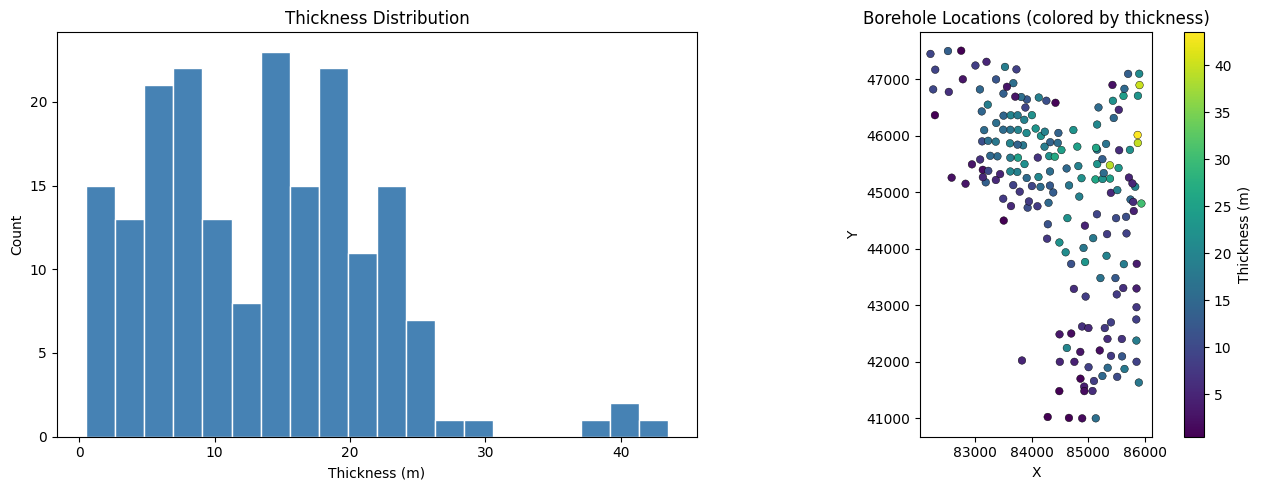

In [4]:
df = load_data(CONFIG['data_path'])
n_total = len(df)
print(f"n = {n_total}")
display(df.describe()[['X', 'Y', 'Z', 'thickness', 'calorific_value', 'coal_top']])

# --- Basic descriptive charts (thickness distribution + spatial coverage) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['thickness'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Thickness (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Thickness Distribution')

sc = axes[1].scatter(df['X'], df['Y'], c=df['thickness'], cmap='viridis', s=30, edgecolor='k', linewidth=0.3)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_aspect('equal')
axes[1].set_title('Borehole Locations (colored by thickness)')
fig.colorbar(sc, ax=axes[1], label='Thickness (m)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_data_overview.png'), dpi=200, bbox_inches='tight')
plt.show()

EVAL_INDICES = select_eval_subset(df, CONFIG['n_folds'], seed=0)
y_true_eval = df['thickness'].values[EVAL_INDICES]

# --- Checkpoint/data mismatch guard ---
# If n_folds (or the data file's CONTENT -- even if the filename stays the same) changes,
# old checkpoints belong to a different data/evaluation set -- if mixed in,
# they silently produce wrong results. To prevent this, we keep both the structural info
# and a CONTENT summary (hash) of the data in a 'fingerprint' file -- this way
# even different content written under the same filename is caught.
import hashlib
_data_hash = hashlib.md5(
    pd.util.hash_pandas_object(df[['X', 'Y', 'thickness', 'coal_top']], index=False).values
).hexdigest()

EVAL_FINGERPRINT_PATH = os.path.join(RESULTS_DIR, 'eval_fingerprint.json')
current_fp = {'n_total': n_total, 'n_folds': CONFIG['n_folds'],
              'eval_indices': EVAL_INDICES.tolist(), 'data_hash': _data_hash}
if os.path.exists(EVAL_FINGERPRINT_PATH):
    saved_fp = load_json(EVAL_FINGERPRINT_PATH, {})
    if saved_fp != current_fp:
        mismatch = 'data_hash' if saved_fp.get('data_hash') != _data_hash else 'n_folds/n_total/eval_indices'
        raise RuntimeError(
            f"MISMATCH ({mismatch}): the checkpoints in 'results/' belong to a different "
            "data/n_folds combination -- this triggers even if the filename stays the SAME but the data "
            "CONTENT changes. DELETE the 'results/' folder and restart this notebook "
            "from the top -- otherwise old and new results will silently mix."
        )
save_json(current_fp, EVAL_FINGERPRINT_PATH)

if CONFIG['n_folds'] is not None:
    sub = df.iloc[EVAL_INDICES]
    print(f"\nEvaluation subset: {len(EVAL_INDICES)}/{n_total} points (stratified-random)")
    print(f"  thickness mean: {sub['thickness'].mean():.2f} (full data: {df['thickness'].mean():.2f})")
    print(f"  thickness std: {sub['thickness'].std():.2f} (full data: {df['thickness'].std():.2f})")
    print(f"  X range: {sub['X'].min():.0f}-{sub['X'].max():.0f} (full data: {df['X'].min():.0f}-{df['X'].max():.0f})")


## 5. Kriging reference model: variogram + trend + anisotropy (deterministic LOOCV)

We run a three-stage, fully automatic search (no number is hardcoded by hand -- the
search re-adjusts itself if the data changes):

1. **Variogram model** (spherical/exponential/gaussian), isotropic OK.
2. **Trend** (plain Ordinary Kriging vs. linearly-trended Universal Kriging), best model held fixed.
3. **Anisotropy** (angle x scaling grid), best model+trend held fixed.

This ordering targets the two things a purely isotropic/stationary OK systematically fails
to capture at this site (trend, direction-dependent correlation) -- prior analysis
confirmed these give a real, consistent R² gain (0.397→~0.417). Kriging is deterministic
so no repetition/seeding is needed here, though the grid search itself may take a few minutes.


In [5]:
import os
path = os.path.join(RESULTS_DIR, 'kriging_final.json')
if os.path.exists(path):
    os.remove(path)
    print("Silindi, Section 5 yeniden hesaplayacak.")
else:
    print("Zaten yok.")

from pykrige.uk import UniversalKriging

def run_kriging_loocv_config(df, variogram_model, drift_terms, anisotropy_scaling, anisotropy_angle,
                              nlags, eval_indices):
    X, Y, Z = df['X'].values, df['Y'].values, df['thickness'].values
    preds = np.zeros(len(eval_indices))
    krig_std = np.zeros(len(eval_indices))
    for j, i in enumerate(eval_indices):
        idx = np.arange(len(df)) != i
        kwargs = dict(variogram_model=variogram_model, nlags=nlags,
                      anisotropy_scaling=anisotropy_scaling, anisotropy_angle=anisotropy_angle,
                      enable_plotting=False)
        if drift_terms:
            k = UniversalKriging(X[idx], Y[idx], Z[idx], drift_terms=drift_terms, **kwargs)
        else:
            k = OrdinaryKriging(X[idx], Y[idx], Z[idx], **kwargs)
        p, s = k.execute('points', np.array([X[i]]), np.array([Y[i]]))
        preds[j] = max(p[0], 0)
        krig_std[j] = np.sqrt(max(s[0], 0))
    return preds, krig_std


# --- CACHE CHECK ---
# This section is deterministic (seedless) but Stage 3's grid search is expensive (~hundreds of
# Kriging fits). Since the fingerprint check in Section 4 already guarantees data/n_folds
# consistency, results can be safely reused if already on disk.
_KRIGING_FINAL_PATH = os.path.join(RESULTS_DIR, 'kriging_final.json')
_PREDS_K_PATH = os.path.join(RESULTS_DIR, 'preds_kriging.npy')
_STD_K_PATH = os.path.join(RESULTS_DIR, 'std_kriging.npy')

if os.path.exists(_KRIGING_FINAL_PATH) and os.path.exists(_PREDS_K_PATH) and os.path.exists(_STD_K_PATH):
    _kf = load_json(_KRIGING_FINAL_PATH, None)
    KRIGING_CONFIG = _kf['kriging_config']
    KRIGING_CONFIG['drift_terms'] = KRIGING_CONFIG['drift_terms'] or None
    KRIGING_LABEL = _kf['label']
    metrics_kriging = _kf['metrics']
    preds_kriging = np.load(_PREDS_K_PATH)
    std_kriging = np.load(_STD_K_PATH)
    best_vm = KRIGING_CONFIG['variogram_model']
    best_angle = KRIGING_CONFIG['anisotropy_angle']
    best_scaling = KRIGING_CONFIG['anisotropy_scaling']
    best_drift_key = 'OK' if not KRIGING_CONFIG['drift_terms'] else 'UK_' + '_'.join(KRIGING_CONFIG['drift_terms'])
    print(f"Kriging reference loaded from cache: {KRIGING_LABEL} (Stages 1-3 not recomputed)")
    print(f"  R2={metrics_kriging['R2']:.4f}, RMSE={metrics_kriging['RMSE']:.4f}")

else:
    t0 = time.time()

    # --- Stage 1: variogram model (isotropic OK) ---
    stage1 = {}
    for vm in CONFIG['kriging_variogram_candidates']:
        preds, std = run_kriging_loocv_config(df, vm, None, 1.0, 0.0, CONFIG['kriging_nlags'], EVAL_INDICES)
        stage1[vm] = {'preds': preds, 'std': std, 'metrics': compute_metrics(y_true_eval, preds)}
    best_vm = min(stage1, key=lambda k: stage1[k]['metrics']['RMSE'])
    print(f"[Stage 1] variogram -> '{best_vm}' [{time.time()-t0:.1f}s]")

    # Full comparison table of the three variogram models -- kept not just for the selection,
    # also retained for the discussion/manuscript.
    variogram_raw_comparison = pd.DataFrame([
        {'variogram_model': vm, **stage1[vm]['metrics']} for vm in CONFIG['kriging_variogram_candidates']
    ]).set_index('variogram_model')
    variogram_raw_comparison.to_csv(os.path.join(RESULTS_DIR, 'kriging_variogram_raw_comparison.csv'))

    # --- Stage 2: trend (OK vs. UK-linear), best_vm fixed ---
    t1 = time.time()
    stage2 = {'OK': stage1[best_vm]}
    for drift in CONFIG['kriging_drift_candidates']:
        if drift is None:
            continue
        preds, std = run_kriging_loocv_config(df, best_vm, list(drift), 1.0, 0.0, CONFIG['kriging_nlags'], EVAL_INDICES)
        stage2['UK_' + '_'.join(drift)] = {'preds': preds, 'std': std, 'metrics': compute_metrics(y_true_eval, preds)}
    best_drift_key = min(stage2, key=lambda k: stage2[k]['metrics']['RMSE'])
    best_drift = None if best_drift_key == 'OK' else ['regional_linear']
    print(f"[Stage 2] trend -> '{best_drift_key}' [{time.time()-t1:.1f}s]")

    # Stage 2's FULL comparison table (not just the winner) -- for reporting/discussion
    stage2_table = pd.DataFrame([
        {'trend': k, **v['metrics']} for k, v in stage2.items()
    ]).set_index('trend')
    stage2_table.to_csv(os.path.join(RESULTS_DIR, 'kriging_stage2_trend_comparison.csv'))

    # --- Stage 3: anisotropy grid, best_vm + best_drift fixed ---
    t2 = time.time()
    stage3 = {}
    for angle in CONFIG['aniso_angles']:
        for scaling in CONFIG['aniso_scalings']:
            preds, std = run_kriging_loocv_config(df, best_vm, best_drift, scaling, angle,
                                                   CONFIG['kriging_nlags'], EVAL_INDICES)
            stage3[(angle, scaling)] = {'preds': preds, 'std': std, 'metrics': compute_metrics(y_true_eval, preds)}
    best_aniso = min(stage3, key=lambda k: stage3[k]['metrics']['RMSE'])
    best_angle, best_scaling = best_aniso
    print(f"[Stage 3] anisotropy -> angle={best_angle}, scale={best_scaling} [{time.time()-t2:.1f}s]")

    # Stage 3's FULL grid table (all angle x scale combinations) -- for reporting/discussion
    stage3_table = pd.DataFrame([
        {'angle': a, 'scaling': s, **stage3[(a, s)]['metrics']}
        for (a, s) in stage3
    ]).sort_values(['angle', 'scaling'])
    stage3_table.to_csv(os.path.join(RESULTS_DIR, 'kriging_stage3_anisotropy_grid.csv'), index=False)
    print(f"TOPLAM: {time.time()-t0:.1f}s")

    KRIGING_CONFIG = {'variogram_model': best_vm, 'drift_terms': best_drift,
                       'anisotropy_angle': best_angle, 'anisotropy_scaling': best_scaling,
                       'nlags': CONFIG['kriging_nlags']}
    KRIGING_LABEL = (f"{'UK' if best_drift else 'OK'}-{best_vm}"
                      f"(angle={best_angle}°,scale={best_scaling})")

    preds_kriging = stage3[best_aniso]['preds']
    std_kriging = stage3[best_aniso]['std']
    metrics_kriging = stage3[best_aniso]['metrics']

    np.save(_PREDS_K_PATH, preds_kriging)
    np.save(_STD_K_PATH, std_kriging)
    save_json({'kriging_config': {**KRIGING_CONFIG, 'drift_terms': KRIGING_CONFIG['drift_terms'] or []},
               'label': KRIGING_LABEL, 'metrics': metrics_kriging}, _KRIGING_FINAL_PATH)

kriging_selection_table = pd.DataFrame([
    {'stage': '1-variogram', 'selected': best_vm},
    {'stage': '2-trend', 'selected': best_drift_key},
    {'stage': '3-anisotropy', 'selected': f'angle={best_angle},scale={best_scaling}', **metrics_kriging},
])
print(f"\nSelected Kriging reference: {KRIGING_LABEL}")
display(kriging_selection_table.round(4))
kriging_selection_table.to_csv(os.path.join(RESULTS_DIR, 'kriging_stage_selection.csv'), index=False)


Silindi, Section 5 yeniden hesaplayacak.
[Stage 1] variogram -> 'exponential' [43.1s]
[Stage 2] trend -> 'UK_regional_linear' [44.1s]
[Stage 3] anisotropy -> angle=90, scale=2.0 [623.3s]
TOPLAM: 711.3s

Selected Kriging reference: UK-exponential(angle=90°,scale=2.0)


,stage,selected,RMSE,MAE,R2,Pearson
0,1-variogram,exponential,NaN,NaN,NaN,NaN
1,2-trend,UK_regional_linear,NaN,NaN,NaN,NaN
2,3-anisotropy,"angle=90,scale=2.0",6.1746,4.7291,0.4173,0.6468


## 6. PINN model (parametric architecture) and fold-wise-scaled LOOCV

`n_hidden` / `n_layers` are supplied externally -> the same function is used for both the
ablation and the final run.
Scalers are fit in every fold using only that fold's training data (no leakage).


In [6]:
class KestirimPINN(nn.Module):
    def __init__(self, n_hidden=256, n_layers=4):
        super().__init__()
        layers = [nn.Linear(2, n_hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.SiLU()]
        layers += [nn.Linear(n_hidden, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(arch):
    m = KestirimPINN(arch['n_hidden'], arch['n_layers'])
    return sum(p.numel() for p in m.parameters())


def run_pinn_loocv_one_seed(df, seed, arch, cfg, eval_indices, device=DEVICE):
    """eval_indices: which points (folds) will be evaluated under LOOCV.
    Every fold's training set is still ALL remaining points of df (len(df)-1) --
    only which points get tested is restricted (when n_folds < len(df)).

    Early stopping: if the loss fails to improve by more than
    CONFIG['early_stop_min_delta'] for CONFIG['early_stop_patience'] epochs,
    the fold's training is cut short. This noticeably reduces total runtime
    with almost no effect on the result (extra epochs after convergence add little anyway).
    """
    set_seed(seed)
    X, Y, Z, TOP = df['X'].values, df['Y'].values, df['thickness'].values, df['coal_top'].values
    preds = np.zeros(len(eval_indices))
    es_patience = cfg.get('early_stop_patience', 300)
    es_min_delta = cfg.get('early_stop_min_delta', 1e-5)

    for j, i in enumerate(eval_indices):
        idx = np.arange(len(df)) != i
        sc_coords = MinMaxScaler().fit(np.c_[X[idx], Y[idx]])
        sc_feat = MinMaxScaler().fit(np.c_[Z[idx], TOP[idx]])

        Xtr = sc_coords.transform(np.c_[X[idx], Y[idx]])
        Ytr = sc_feat.transform(np.c_[Z[idx], TOP[idx]])
        Xte = sc_coords.transform(np.c_[[X[i]], [Y[i]]])

        Xtr_t = torch.tensor(Xtr, dtype=torch.float32, requires_grad=True, device=device)
        Ytr_t = torch.tensor(Ytr, dtype=torch.float32, device=device)
        Xte_t = torch.tensor(Xte, dtype=torch.float32, device=device)

        model = KestirimPINN(arch['n_hidden'], arch['n_layers']).to(device)
        opt = optim.Adam(model.parameters(), lr=cfg['lr'])
        sched = ReduceLROnPlateau(opt, mode='min', factor=cfg['sched_factor'],
                                   patience=cfg['sched_patience'])
        mse = nn.MSELoss()

        best_loss = float('inf')
        stale_epochs = 0
        for ep in range(cfg['epochs']):
            opt.zero_grad()
            pred = model(Xtr_t)
            loss_data = mse(pred, Ytr_t)
            grad = torch.autograd.grad(
                pred[:, 0], Xtr_t, grad_outputs=torch.ones_like(pred[:, 0]),
                create_graph=True, retain_graph=True)[0]
            loss_spatial = torch.mean(torch.abs(grad))
            loss = loss_data + cfg['lambda_spatial'] * loss_spatial
            loss.backward()
            opt.step()
            loss_val = loss.item()
            sched.step(loss_val)

            if loss_val < best_loss - es_min_delta:
                best_loss = loss_val
                stale_epochs = 0
            else:
                stale_epochs += 1
            if stale_epochs >= es_patience:
                break

        model.eval()
        with torch.no_grad():
            pn = model(Xte_t).cpu().numpy()
        thickness_real = sc_feat.inverse_transform(np.c_[pn[:, 0], [0]])[0, 0]
        preds[j] = max(thickness_real, 0)

    return preds


## 7. Capacity ablation: small / medium / large architecture (checkpointed)

Each (architecture, seed) pair is an independent LOOCV run. The checkpoint file is keyed
by both architecture and seed -- if interrupted, it resumes exactly where it left off.


In [7]:
ABL_CKPT_PATH = os.path.join(RESULTS_DIR, 'pinn_ablation_checkpoint.json')
ablation_ckpt = load_json(ABL_CKPT_PATH, {})   # {"arch__seed": {"preds":[...], "metrics":{...}}}

total_runs = len(CONFIG['architectures']) * len(CONFIG['ablation_seeds'])
done = 0
for arch_name, arch in CONFIG['architectures'].items():
    for seed in CONFIG['ablation_seeds']:
        key = f"{arch_name}__{seed}"
        done += 1
        if key in ablation_ckpt:
            print(f"[{done}/{total_runs}] {key} already completed, skipping "
                  f"(R2={ablation_ckpt[key]['metrics']['R2']:.4f})")
            continue
        t0 = time.time()
        preds = run_pinn_loocv_one_seed(df, seed, arch, CONFIG, EVAL_INDICES)
        m = compute_metrics(y_true_eval, preds)
        ablation_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
        save_json(ablation_ckpt, ABL_CKPT_PATH)
        print(f"[{done}/{total_runs}] {key} completed [{time.time()-t0:.1f}s] -> "
              f"R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nTotal {len(ablation_ckpt)}/{total_runs} (architecture,seed) runs completed.")


[1/18] small__0 already completed, skipping (R2=0.2169)
[2/18] small__1 already completed, skipping (R2=0.2209)
[3/18] small__2 already completed, skipping (R2=0.2121)
[4/18] small__3 already completed, skipping (R2=0.2322)
[5/18] small__4 already completed, skipping (R2=0.2282)
[6/18] small__5 already completed, skipping (R2=0.2360)
[7/18] medium__0 already completed, skipping (R2=0.2417)
[8/18] medium__1 already completed, skipping (R2=0.2451)
[9/18] medium__2 already completed, skipping (R2=0.2440)
[10/18] medium__3 already completed, skipping (R2=0.2439)
[11/18] medium__4 already completed, skipping (R2=0.2457)
[12/18] medium__5 already completed, skipping (R2=0.2460)
[13/18] large__0 already completed, skipping (R2=0.2942)
[14/18] large__1 already completed, skipping (R2=0.2913)
[15/18] large__2 already completed, skipping (R2=0.2933)
[16/18] large__3 already completed, skipping (R2=0.3020)
[17/18] large__4 already completed, skipping (R2=0.3136)
[18/18] large__5 already completed

## 8. Ablation summary and architecture selection

CAPACITY ABLATION SUMMARY


,n_params,n_seeds,R2_mean,R2_std,RMSE_mean,RMSE_std
architecture,,,,,,
small,1218,6,0.2244,0.0093,7.1234,0.0426
medium,8642,6,0.2444,0.0016,7.0309,0.0074
large,198658,6,0.2980,0.0085,6.7771,0.0411



Referans -- Kriging (UK-exponential(angle=90°,scale=2.0)): R2=0.4173, RMSE=6.1746

>>> Automatically selected architecture: 'large' (highest mean R2). If needed, check the table above and manually change the SELECTED_ARCHITECTURE variable.


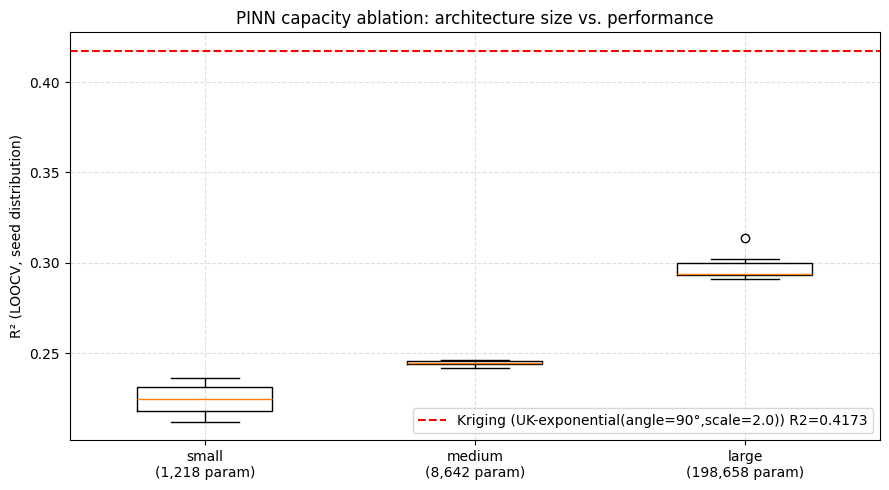

In [8]:
rows = []
for arch_name in CONFIG['architectures']:
    arch_seed_metrics = pd.DataFrame({
        s: ablation_ckpt[f"{arch_name}__{s}"]['metrics']
        for s in CONFIG['ablation_seeds'] if f"{arch_name}__{s}" in ablation_ckpt
    }).T.astype(float)
    rows.append({
        'architecture': arch_name,
        'n_params': count_params(CONFIG['architectures'][arch_name]),
        'n_seeds': len(arch_seed_metrics),
        'R2_mean': arch_seed_metrics['R2'].mean(),
        'R2_std': arch_seed_metrics['R2'].std(),
        'RMSE_mean': arch_seed_metrics['RMSE'].mean(),
        'RMSE_std': arch_seed_metrics['RMSE'].std(),
    })

ablation_summary = pd.DataFrame(rows).set_index('architecture')
print("="*70)
print("CAPACITY ABLATION SUMMARY")
print("="*70)
display(ablation_summary.round(4))
print(f"\nReferans -- Kriging ({KRIGING_LABEL}): R2={metrics_kriging['R2']:.4f}, "
      f"RMSE={metrics_kriging['RMSE']:.4f}")

# Automatic selection: highest mean R2. By manually editing this line
# (e.g. 'medium') you could also select a smaller architecture on diminishing-returns grounds.
SELECTED_ARCHITECTURE = ablation_summary['R2_mean'].idxmax()
print(f"\n>>> Automatically selected architecture: '{SELECTED_ARCHITECTURE}' "
      f"(highest mean R2). If needed, check the table above and "
      f"manually change the SELECTED_ARCHITECTURE variable.")

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(CONFIG['architectures']))
data_for_box = [
    [ablation_ckpt[f"{a}__{s}"]['metrics']['R2'] for s in CONFIG['ablation_seeds']
     if f"{a}__{s}" in ablation_ckpt]
    for a in CONFIG['architectures']
]
ax.boxplot(data_for_box, positions=positions, widths=0.5)
ax.set_xticks(list(positions))
ax.set_xticklabels([f"{a}\n({count_params(CONFIG['architectures'][a]):,} param)"
                     for a in CONFIG['architectures']])
ax.axhline(metrics_kriging['R2'], color='red', linestyle='--',
           label=f"Kriging ({KRIGING_LABEL}) R2={metrics_kriging['R2']:.4f}")
ax.set_ylabel('R² (LOOCV, seed distribution)')
ax.set_title('PINN capacity ablation: architecture size vs. performance')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'capacity_ablation.png'), dpi=150)
plt.show()

ablation_summary.to_csv(os.path.join(RESULTS_DIR, 'capacity_ablation_summary.csv'))


## 9. Additional seeds for the selected architecture + ensemble prediction

Seeds from the `final_seeds` list that have not yet been run are added (the checkpoint
uses the same file and the same keying scheme). The result is the ensemble (seed-averaged)
prediction of the selected architecture.


In [9]:
arch = CONFIG['architectures'][SELECTED_ARCHITECTURE]
extra_seeds = [s for s in CONFIG['final_seeds'] if f"{SELECTED_ARCHITECTURE}__{s}" not in ablation_ckpt]
print(f"Running {len(extra_seeds)} additional seeds for architecture '{SELECTED_ARCHITECTURE}' "
      f"(zaten {sum(1 for s in CONFIG['final_seeds'] if f'{SELECTED_ARCHITECTURE}__{s}' in ablation_ckpt)} tanesi mevcut).")

for seed in extra_seeds:
    key = f"{SELECTED_ARCHITECTURE}__{seed}"
    t0 = time.time()
    preds = run_pinn_loocv_one_seed(df, seed, arch, CONFIG, EVAL_INDICES)
    m = compute_metrics(y_true_eval, preds)
    ablation_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(ablation_ckpt, ABL_CKPT_PATH)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}")

final_seed_keys = [f"{SELECTED_ARCHITECTURE}__{s}" for s in CONFIG['final_seeds']
                    if f"{SELECTED_ARCHITECTURE}__{s}" in ablation_ckpt]
all_preds = np.array([ablation_ckpt[k]['preds'] for k in final_seed_keys])
preds_pinn_ensemble = all_preds.mean(axis=0)
std_pinn_ensemble = all_preds.std(axis=0)   # seed-to-seed spread -> uncertainty proxy
metrics_pinn_ensemble = compute_metrics(y_true_eval, preds_pinn_ensemble)

print(f"\nEnsemble ({len(final_seed_keys)} seed, mimari='{SELECTED_ARCHITECTURE}') metrikleri:")
print(json.dumps(metrics_pinn_ensemble, indent=2))

np.save(os.path.join(RESULTS_DIR, 'preds_pinn_ensemble.npy'), preds_pinn_ensemble)
np.save(os.path.join(RESULTS_DIR, 'std_pinn_ensemble.npy'), std_pinn_ensemble)
save_json({'architecture': SELECTED_ARCHITECTURE, 'n_seeds': len(final_seed_keys),
           'metrics': metrics_pinn_ensemble},
          os.path.join(RESULTS_DIR, 'pinn_final.json'))


Running 0 additional seeds for architecture 'large' (zaten 20 tanesi mevcut).

Ensemble (20 seed, mimari='large') metrikleri:
{
  "RMSE": 6.7178027384013586,
  "MAE": 5.226688171166278,
  "R2": 0.31021417100060755,
  "Pearson": 0.557200284673008
}


## 10. Uncertainty calibration: Kriging variance vs. PINN ensemble spread

A well-calibrated uncertainty estimate should be positively associated with the actual
error (higher spread should tend to mean higher error), and the nominal 95% interval
should cover roughly 95% of the true values. We compare both methods on these two criteria.


UNCERTAINTY CALIBRATION COMPARISON


,"spearman(std, |error|)",spearman_p,nominal_95pct_coverage
method,,,
"UK-exponential(angle=90°,scale=2.0)",-0.0670,0.35682,0.9215
PINN ensemble (large),0.0416,0.56801,0.1099



Interpretation: if the spearman coefficient is near 0 or p>=0.05, the
method's predicted uncertainty (std/variance) is NOT related to the actual error --
it gives no reliable answer to 'where am I uncertain'. If coverage is notably
far from 0.95, the confidence intervals are miscalibrated (too narrow/too wide).


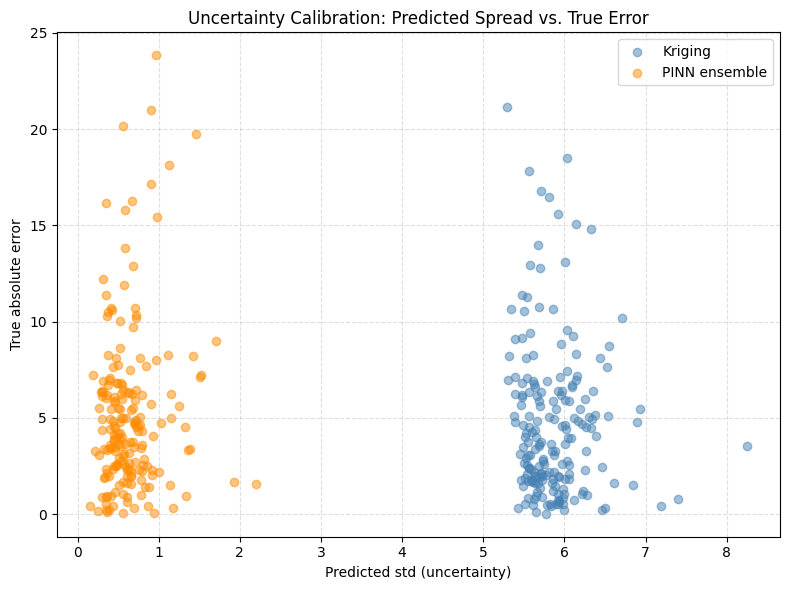

In [10]:
def calibration_report(y_true, preds, std, label):
    abs_err = np.abs(y_true - preds)
    rho, p = spearmanr(std, abs_err)
    lower, upper = preds - 1.96 * std, preds + 1.96 * std
    coverage = float(np.mean((y_true >= lower) & (y_true <= upper)))
    return {
        'method': label,
        'spearman(std, |error|)': round(float(rho), 4),
        'spearman_p': round(float(p), 5),
        'nominal_95pct_coverage': round(coverage, 4),
    }

calib_kriging = calibration_report(y_true_eval, preds_kriging, std_kriging, KRIGING_LABEL)
calib_pinn = calibration_report(y_true_eval, preds_pinn_ensemble, std_pinn_ensemble,
                                 f'PINN ensemble ({SELECTED_ARCHITECTURE})')

calibration_table = pd.DataFrame([calib_kriging, calib_pinn]).set_index('method')
print("="*70)
print("UNCERTAINTY CALIBRATION COMPARISON")
print("="*70)
display(calibration_table)
print("\nInterpretation: if the spearman coefficient is near 0 or p>=0.05, the")
print("method's predicted uncertainty (std/variance) is NOT related to the actual error --")
print("it gives no reliable answer to 'where am I uncertain'. If coverage is notably")
print("far from 0.95, the confidence intervals are miscalibrated (too narrow/too wide).")

calibration_table.to_csv(os.path.join(RESULTS_DIR, 'uncertainty_calibration.csv'))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(std_kriging, np.abs(y_true_eval - preds_kriging), alpha=0.5, label='Kriging', color='steelblue')
ax.scatter(std_pinn_ensemble, np.abs(y_true_eval - preds_pinn_ensemble), alpha=0.5,
           label='PINN ensemble', color='darkorange')
ax.set_xlabel('Predicted std (uncertainty)')
ax.set_ylabel('True absolute error')
ax.set_title('Uncertainty Calibration: Predicted Spread vs. True Error')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'uncertainty_calibration.png'), dpi=150)
plt.show()


## 11. Paired Wilcoxon significance test: Kriging vs. PINN ensemble

In [11]:
err_kriging = np.abs(y_true_eval - preds_kriging)
err_pinn = np.abs(y_true_eval - preds_pinn_ensemble)

stat, p_value = wilcoxon(err_kriging, err_pinn)

print("="*70)
print(f"Paired Wilcoxon: Kriging ({KRIGING_LABEL}) vs PINN ensemble ({SELECTED_ARCHITECTURE})")
print("="*70)
print(f"Statistic: {stat:.4f} | p-value: {p_value:.5f}")
if p_value < 0.05:
    kazanan = 'PINN' if err_pinn.mean() < err_kriging.mean() else 'Kriging'
    print(f"-> p < 0.05: the difference is statistically significant. Lower mean absolute error: {kazanan}")
else:
    print("-> p >= 0.05: the difference is NOT statistically significant.")
    print("   The manuscript should report 'X and Y show comparable performance', not")
    print("   'X is superior to Y'.")

save_json({'statistic': float(stat), 'p_value': float(p_value)},
          os.path.join(RESULTS_DIR, 'wilcoxon_test.json'))


Paired Wilcoxon: Kriging (UK-exponential(angle=90°,scale=2.0)) vs PINN ensemble (large)
Statistic: 6341.0000 | p-value: 0.00022
-> p < 0.05: the difference is statistically significant. Lower mean absolute error: Kriging


## 12. Final summary table

In [12]:
# --- This cell relies on results SAVED TO DISK, not on variables left over
# in memory -- so it runs correctly and consistently even after a session
# reconnect / when cells are run out of order (this was exactly the cause
# of an earlier NameError). ---
_kriging_final = load_json(os.path.join(RESULTS_DIR, 'kriging_final.json'), None)
_pinn_final = load_json(os.path.join(RESULTS_DIR, 'pinn_final.json'), None)
_wilcoxon = load_json(os.path.join(RESULTS_DIR, 'wilcoxon_test.json'), None)

missing = [name for name, val in [('kriging_final.json', _kriging_final),
                                    ('pinn_final.json', _pinn_final),
                                    ('wilcoxon_test.json', _wilcoxon)] if val is None]
if missing:
    raise RuntimeError(
        f"These result files are not yet on disk: {missing}. Please first run the "
        "relevant sections (Kriging reference / PINN ensemble / Wilcoxon test)."
    )

_kriging_label = _kriging_final['label']
_kriging_metrics = _kriging_final['metrics']
_pinn_arch = _pinn_final['architecture']
_pinn_n_seeds = _pinn_final['n_seeds']
_pinn_metrics = _pinn_final['metrics']
_p_value = _wilcoxon['p_value']

final_summary = pd.DataFrame({
    'Method': [f'Kriging ({_kriging_label})',
               f'PINN ensemble ({_pinn_arch}, n={_pinn_n_seeds} seed)'],
    'RMSE': [_kriging_metrics['RMSE'], _pinn_metrics['RMSE']],
    'MAE': [_kriging_metrics['MAE'], _pinn_metrics['MAE']],
    'R2': [_kriging_metrics['R2'], _pinn_metrics['R2']],
    'Pearson': [_kriging_metrics['Pearson'], _pinn_metrics['Pearson']],
})

print("="*90)
print("FINAL COMPARISON TABLE")
print("="*90)
display(final_summary.round(4))
print(f"\nWilcoxon p-value: {_p_value:.5f}")
print(f"Selected Kriging reference: {_kriging_label}")
print(f"Selected PINN architecture: {_pinn_arch} ({count_params(CONFIG['architectures'][_pinn_arch]):,} parameters)")
print(f"\nAll intermediate/final outputs saved to the '{RESULTS_DIR}/' folder (including checkpoints).")

final_summary.to_csv(os.path.join(RESULTS_DIR, 'final_summary.csv'), index=False)


FINAL COMPARISON TABLE


,Method,RMSE,MAE,R2,Pearson
0,"Kriging (UK-exponential(angle=90°,scale=2.0))",6.1746,4.7291,0.4173,0.6468
1,"PINN ensemble (large, n=20 seed)",6.7178,5.2267,0.3102,0.5572



Wilcoxon p-value: 0.00022
Selected Kriging reference: UK-exponential(angle=90°,scale=2.0)
Selected PINN architecture: large (198,658 parameters)

All intermediate/final outputs saved to the '/content/drive/MyDrive/kriging_vs_pinn_results/' folder (including checkpoints).


## Notes

- Growing the `CONFIG['ablation_seeds']` and `CONFIG['final_seeds']` lists is safe thanks
  to checkpointing -- (architecture, seed) pairs already completed are not rerun.
- **If you change `CONFIG['n_folds']` or update the data file, DELETE the `results/`
  folder and restart.** The notebook now checks this automatically (the fingerprint check
  in Section 4) and raises an error and stops on mismatch -- this prevents old and new
  results from silently mixing.
- When `n_folds < n`, evaluation is not the "first N rows" of the data but a stratified-random
  subset that preserves the thickness distribution (`select_eval_subset`) -- this makes
  small-scale trial results a realistic indicator of the full-data result.
- PINN training uses early stopping (`early_stop_patience`); if a fold's loss fails to
  improve for the specified number of epochs, training is cut short.
- Co-Kriging/LMC and block-model/reserve estimation are outside this notebook's scope --
  to be addressed separately, at a later stage.


## 13. Hypothesis test: is the old notebook's scheduler setting actually better?

The old (exploratory) notebook's "Final PINN" configuration used `patience=10, factor=0.25`;
we used `patience=30, factor=0.3` in the capacity ablation. We measure whether this
difference has a real effect or is just noise, with a **paired** test: same 6 seeds,
`large` architecture, full LOOCV, the scheduler setting as the sole difference. Values for
`current` (patience=30/factor=0.3) already exist in the ablation checkpoint -- only 6 new
runs are needed for `legacy` (patience=10/factor=0.25).

**Time estimate:** the `large` architecture takes ~110-120 minutes per seed (see the
previous run); 6 seeds is ~11-12 hours. Thanks to the Google Drive checkpoint, this can
also be safely split into batches (e.g., 2-3-seed sessions).


In [13]:
HPARAM_CKPT_PATH = os.path.join(RESULTS_DIR, 'pinn_hparam_test_checkpoint.json')
hparam_ckpt = load_json(HPARAM_CKPT_PATH, {})

HPARAM_TEST_SEEDS = CONFIG['ablation_seeds']   # these seeds already exist in the ablation for 'current'
arch_large = CONFIG['architectures']['large']

legacy_cfg = dict(CONFIG)
legacy_cfg['sched_factor'] = 0.25
legacy_cfg['sched_patience'] = 10

# Safety check: are 'current' (large) results present in the ablation checkpoint?
missing_current = [s for s in HPARAM_TEST_SEEDS if f"large__{s}" not in ablation_ckpt]
if missing_current:
    raise RuntimeError(
        f"Missing seeds in the ablation for the 'large' architecture: {missing_current}. "
        "First complete the ablation cell in Section 7 for these seeds."
    )

for seed in HPARAM_TEST_SEEDS:
    key = f"legacy__{seed}"
    if key in hparam_ckpt:
        print(f"{key} already completed, skipping (R2={hparam_ckpt[key]['metrics']['R2']:.4f})")
        continue
    t0 = time.time()
    preds = run_pinn_loocv_one_seed(df, seed, arch_large, legacy_cfg, EVAL_INDICES)
    m = compute_metrics(y_true_eval, preds)
    hparam_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(hparam_ckpt, HPARAM_CKPT_PATH)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nToplam {sum(1 for s in HPARAM_TEST_SEEDS if f'legacy__{s}' in hparam_ckpt)}/{len(HPARAM_TEST_SEEDS)} "
      f"'legacy' runs completed.")


legacy__0 already completed, skipping (R2=0.2251)
legacy__1 already completed, skipping (R2=0.1876)
legacy__2 already completed, skipping (R2=0.1741)
legacy__3 already completed, skipping (R2=0.1699)
legacy__4 already completed, skipping (R2=0.1568)
legacy__5 already completed, skipping (R2=0.2019)

Toplam 6/6 'legacy' runs completed.


In [14]:
current_r2 = [ablation_ckpt[f"large__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]
legacy_r2 = [hparam_ckpt[f"legacy__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]

print("="*70)
print("PAIRED COMPARISON: current (patience=30/factor=0.3) vs "
      "legacy (patience=10/factor=0.25)")
print("="*70)
comparison = pd.DataFrame({'seed': HPARAM_TEST_SEEDS, 'current_R2': current_r2, 'legacy_R2': legacy_r2})
comparison['fark_legacy_minus_current'] = comparison['legacy_R2'] - comparison['current_R2']
display(comparison)

print(f"\ncurrent mean R2: {np.mean(current_r2):.4f} (std={np.std(current_r2):.4f})")
print(f"legacy  mean R2: {np.mean(legacy_r2):.4f} (std={np.std(legacy_r2):.4f})")

stat, p_hparam = wilcoxon(current_r2, legacy_r2)
print(f"\nPaired Wilcoxon: statistic={stat:.4f}, p={p_hparam:.5f}")
if p_hparam < 0.05:
    yon = 'legacy > current' if np.mean(legacy_r2) > np.mean(current_r2) else 'current > legacy'
    print(f"-> p < 0.05: the scheduler setting has a REAL effect ({yon}). "
          f"Consider updating the config accordingly and re-evaluating the ablation with this setting.")
else:
    print("-> p >= 0.05: NO significant difference between the two scheduler settings. "
          "The old notebook's high R2 likely did not come from the scheduler choice, but "
          "from reporting the best of an untracked number of trials (cherry-picking).")

comparison.to_csv(os.path.join(RESULTS_DIR, 'hparam_hypothesis_test.csv'), index=False)
save_json({'p_value': float(p_hparam), 'current_mean': float(np.mean(current_r2)),
           'legacy_mean': float(np.mean(legacy_r2))},
          os.path.join(RESULTS_DIR, 'hparam_hypothesis_summary.json'))


PAIRED COMPARISON: current (patience=30/factor=0.3) vs legacy (patience=10/factor=0.25)


,seed,current_R2,legacy_R2,fark_legacy_minus_current
0,0,0.294187,0.225115,-0.069072
1,1,0.291265,0.187568,-0.103696
2,2,0.293331,0.174128,-0.119203
3,3,0.301959,0.169889,-0.132070
4,4,0.313568,0.156773,-0.156795
5,5,0.293486,0.201877,-0.091609



current mean R2: 0.2980 (std=0.0077)
legacy  mean R2: 0.1859 (std=0.0225)

Paired Wilcoxon: statistic=0.0000, p=0.03125
-> p < 0.05: the scheduler setting has a REAL effect (current > legacy). Consider updating the config accordingly and re-evaluating the ablation with this setting.


## 16. Second hypothesis test: the old notebook's learning rate (lr) + epoch count

Seeing the old "Final" configuration's exact parameters revealed: the architecture and
scheduler (`patience=30, factor=0.3`) were already identical to `current` (we had already
tested this correctly in Sections 13-15) -- but **`lr=0.001`** (**10 times** the `0.0001`
we used) and **`epochs=1000`** (half of ours) were two dimensions that had never been
tested.

Numerical stability was checked (10x higher lr does not produce NaN/divergence with the
gradient-based spatial penalty). We now measure its real effect with the same paired
method (6 shared seeds, `large` architecture).

**Note:** two parameters (lr AND epoch) change together here -- this test answers "does
the old full configuration package work?" If a significant difference appears, we can
test the two separately afterward to isolate which one (or their interaction) is
responsible.


In [15]:
NIHAI_CKPT_PATH = os.path.join(RESULTS_DIR, 'pinn_nihai_orig_checkpoint.json')
nihai_ckpt = load_json(NIHAI_CKPT_PATH, {})

nihai_orig_cfg = dict(CONFIG)
nihai_orig_cfg['lr'] = 0.001
nihai_orig_cfg['epochs'] = 1000
nihai_orig_cfg['sched_factor'] = 0.3
nihai_orig_cfg['sched_patience'] = 30

arch_large = CONFIG['architectures']['large']
missing_current = [s for s in HPARAM_TEST_SEEDS if f"large__{s}" not in ablation_ckpt]
if missing_current:
    raise RuntimeError(f"Missing seeds in the ablation for 'large': {missing_current}")

for seed in HPARAM_TEST_SEEDS:
    key = f"nihai_orig__{seed}"
    if key in nihai_ckpt:
        print(f"{key} already completed, skipping (R2={nihai_ckpt[key]['metrics']['R2']:.4f})")
        continue
    t0 = time.time()
    preds = run_pinn_loocv_one_seed(df, seed, arch_large, nihai_orig_cfg, EVAL_INDICES)
    m = compute_metrics(y_true_eval, preds)
    nihai_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(nihai_ckpt, NIHAI_CKPT_PATH)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nToplam {sum(1 for s in HPARAM_TEST_SEEDS if f'nihai_orig__{s}' in nihai_ckpt)}/"
      f"{len(HPARAM_TEST_SEEDS)} 'nihai_orig' runs completed.")


nihai_orig__0 already completed, skipping (R2=0.3352)
nihai_orig__1 already completed, skipping (R2=0.3718)
nihai_orig__2 already completed, skipping (R2=0.3664)
nihai_orig__3 already completed, skipping (R2=0.3849)
nihai_orig__4 already completed, skipping (R2=0.3779)
nihai_orig__5 already completed, skipping (R2=0.3860)

Toplam 6/6 'nihai_orig' runs completed.


In [16]:
current_r2_v2 = [ablation_ckpt[f"large__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]
nihai_r2 = [nihai_ckpt[f"nihai_orig__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]

print("="*70)
print("PAIRED COMPARISON: current (lr=1e-4/epoch=2000) vs "
      "nihai_orig (lr=1e-3/epoch=1000)")
print("="*70)
comparison2 = pd.DataFrame({'seed': HPARAM_TEST_SEEDS, 'current_R2': current_r2_v2, 'nihai_orig_R2': nihai_r2})
comparison2['fark'] = comparison2['nihai_orig_R2'] - comparison2['current_R2']
display(comparison2)

print(f"\ncurrent mean R2:    {np.mean(current_r2_v2):.4f} (std={np.std(current_r2_v2):.4f})")
print(f"nihai_orig mean R2: {np.mean(nihai_r2):.4f} (std={np.std(nihai_r2):.4f})")

stat2, p_nihai = wilcoxon(current_r2_v2, nihai_r2)
print(f"\nPaired Wilcoxon: statistic={stat2:.4f}, p={p_nihai:.5f}")
if p_nihai < 0.05:
    yon = 'nihai_orig > current' if np.mean(nihai_r2) > np.mean(current_r2_v2) else 'current > nihai_orig'
    print(f"-> p < 0.05: there is a REAL effect ({yon}).")
    if np.mean(nihai_r2) > np.mean(current_r2_v2):
        print("   This deserves serious integration into the config -- let's test lr and epoch")
        print("   separately to determine which one is responsible.")
else:
    print("-> p >= 0.05: NO significant difference. The lr/epoch combination also does not")
    print("   explain the old notebook's high R2 -- the cherry-picking hypothesis is reinforced once again.")

comparison2.to_csv(os.path.join(RESULTS_DIR, 'nihai_orig_hypothesis_test.csv'), index=False)
save_json({'p_value': float(p_nihai), 'current_mean': float(np.mean(current_r2_v2)),
           'nihai_orig_mean': float(np.mean(nihai_r2))},
          os.path.join(RESULTS_DIR, 'nihai_orig_hypothesis_summary.json'))


PAIRED COMPARISON: current (lr=1e-4/epoch=2000) vs nihai_orig (lr=1e-3/epoch=1000)


,seed,current_R2,nihai_orig_R2,fark
0,0,0.294187,0.335164,0.040977
1,1,0.291265,0.371814,0.080550
2,2,0.293331,0.366394,0.073064
3,3,0.301959,0.384867,0.082908
4,4,0.313568,0.377885,0.064317
5,5,0.293486,0.385987,0.092501



current mean R2:    0.2980 (std=0.0077)
nihai_orig mean R2: 0.3704 (std=0.0172)

Paired Wilcoxon: statistic=0.0000, p=0.03125
-> p < 0.05: there is a REAL effect (nihai_orig > current).
   This deserves serious integration into the config -- let's test lr and epoch
   separately to determine which one is responsible.


## 17. Third hypothesis test: separating the effect of lr from epoch count

`nihai_orig` (lr=1e-3, epoch=1000) significantly beat `current` (lr=1e-4, epoch=2000)
(p=0.03125, 6/6 seeds in the same direction). But lr AND epoch had changed together. We
now test `lr=1e-3` at the **full epoch budget (2000)** to separate whether the gain
genuinely comes from lr, or whether we happened to land on a random saturation point at
1000 epochs.


In [17]:
LR_ONLY_CKPT_PATH = os.path.join(RESULTS_DIR, 'pinn_lr_only_checkpoint.json')
lr_only_ckpt = load_json(LR_ONLY_CKPT_PATH, {})

nihai_lr_only_cfg = dict(CONFIG)
nihai_lr_only_cfg['lr'] = 0.001
nihai_lr_only_cfg['epochs'] = 2000
nihai_lr_only_cfg['sched_factor'] = 0.3
nihai_lr_only_cfg['sched_patience'] = 30

arch_large = CONFIG['architectures']['large']

for seed in HPARAM_TEST_SEEDS:
    key = f"lr_only__{seed}"
    if key in lr_only_ckpt:
        print(f"{key} already completed, skipping (R2={lr_only_ckpt[key]['metrics']['R2']:.4f})")
        continue
    t0 = time.time()
    preds = run_pinn_loocv_one_seed(df, seed, arch_large, nihai_lr_only_cfg, EVAL_INDICES)
    m = compute_metrics(y_true_eval, preds)
    lr_only_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(lr_only_ckpt, LR_ONLY_CKPT_PATH)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nToplam {sum(1 for s in HPARAM_TEST_SEEDS if f'lr_only__{s}' in lr_only_ckpt)}/"
      f"{len(HPARAM_TEST_SEEDS)} 'lr_only' runs completed.")


lr_only__0 already completed, skipping (R2=0.3750)
lr_only__1 already completed, skipping (R2=0.3714)
lr_only__2 already completed, skipping (R2=0.3680)
lr_only__3 already completed, skipping (R2=0.3362)
lr_only__4 already completed, skipping (R2=0.3961)
lr_only__5 already completed, skipping (R2=0.3527)

Toplam 6/6 'lr_only' runs completed.


In [18]:
nihai_r2_v2 = [nihai_ckpt[f"nihai_orig__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]
lr_only_r2 = [lr_only_ckpt[f"lr_only__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]

print("="*70)
print("PAIRED COMPARISON: nihai_orig (lr=1e-3/epoch=1000) vs "
      "lr_only (lr=1e-3/epoch=2000)")
print("="*70)
comparison3 = pd.DataFrame({'seed': HPARAM_TEST_SEEDS, 'nihai_orig_R2': nihai_r2_v2, 'lr_only_R2': lr_only_r2})
comparison3['fark'] = comparison3['lr_only_R2'] - comparison3['nihai_orig_R2']
display(comparison3)

print(f"\nnihai_orig mean R2: {np.mean(nihai_r2_v2):.4f} (std={np.std(nihai_r2_v2):.4f})")
print(f"lr_only mean R2:    {np.mean(lr_only_r2):.4f} (std={np.std(lr_only_r2):.4f})")

stat3, p_lr_only = wilcoxon(nihai_r2_v2, lr_only_r2)
print(f"\nPaired Wilcoxon: statistic={stat3:.4f}, p={p_lr_only:.5f}")
if p_lr_only < 0.05:
    yon = 'lr_only > nihai_orig (more epochs help)' if np.mean(lr_only_r2) > np.mean(nihai_r2_v2) \
          else 'nihai_orig > lr_only (1000 epochs is a sweet spot, more hurts)'
    print(f"-> p < 0.05: {yon}")
else:
    print("-> p >= 0.05: epoch count (1000 vs 2000, lr=1e-3 fixed) has no additional effect.")
    print("   The real driver is lr -- epoch=1000 was already sufficient, which is good news computationally too.")

# let's also compare directly against current (pure lr effect, epoch=2000 fixed)
current_r2_v3 = [ablation_ckpt[f"large__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]
stat4, p_pure_lr = wilcoxon(current_r2_v3, lr_only_r2)
print(f"\nSaf lr etkisi (epoch=2000 sabit): current ort={np.mean(current_r2_v3):.4f} vs "
      f"lr_only ort={np.mean(lr_only_r2):.4f}, p={p_pure_lr:.5f}")

comparison3.to_csv(os.path.join(RESULTS_DIR, 'lr_only_hypothesis_test.csv'), index=False)
save_json({'p_value_vs_nihai_orig': float(p_lr_only), 'p_value_vs_current': float(p_pure_lr),
           'lr_only_mean': float(np.mean(lr_only_r2))},
          os.path.join(RESULTS_DIR, 'lr_only_hypothesis_summary.json'))


PAIRED COMPARISON: nihai_orig (lr=1e-3/epoch=1000) vs lr_only (lr=1e-3/epoch=2000)


,seed,nihai_orig_R2,lr_only_R2,fark
0,0,0.335164,0.375014,0.039851
1,1,0.371814,0.371369,-0.000445
2,2,0.366394,0.368034,0.001639
3,3,0.384867,0.336162,-0.048704
4,4,0.377885,0.396112,0.018227
5,5,0.385987,0.352744,-0.033244



nihai_orig mean R2: 0.3704 (std=0.0172)
lr_only mean R2:    0.3666 (std=0.0186)

Paired Wilcoxon: statistic=10.0000, p=1.00000
-> p >= 0.05: epoch count (1000 vs 2000, lr=1e-3 fixed) has no additional effect.
   The real driver is lr -- epoch=1000 was already sufficient, which is good news computationally too.

Saf lr etkisi (epoch=2000 sabit): current ort=0.2980 vs lr_only ort=0.3666, p=0.03125


## 18. Final comparison: improved PINN (lr=1e-3, epoch=1000) vs. Kriging

Three controlled tests clarified this: `lr=1e-3` is a real improvement, `epoch=1000` is
already sufficient. This section runs NO new PINN training -- it takes the ensemble
average of the 6 seeds already sitting in the `nihai_orig` checkpoint and runs the **real,
final** paired Wilcoxon test against the Kriging reference. No computational cost, just
aggregation.


In [19]:
nihai_seed_keys = [f"nihai_orig__{s}" for s in HPARAM_TEST_SEEDS if f"nihai_orig__{s}" in nihai_ckpt]
nihai_all_preds = np.array([nihai_ckpt[k]['preds'] for k in nihai_seed_keys])
preds_pinn_improved = nihai_all_preds.mean(axis=0)
std_pinn_improved = nihai_all_preds.std(axis=0)
metrics_pinn_improved = compute_metrics(y_true_eval, preds_pinn_improved)

print(f"Improved PINN ensemble ({len(nihai_seed_keys)} seeds, lr=1e-3/epoch=1000):")
print(json.dumps(metrics_pinn_improved, indent=2))
print(f"\nKriging reference ({KRIGING_LABEL}):")
print(json.dumps(metrics_kriging, indent=2))

err_kriging_v2 = np.abs(y_true_eval - preds_kriging)
err_pinn_improved = np.abs(y_true_eval - preds_pinn_improved)
stat_final, p_final = wilcoxon(err_kriging_v2, err_pinn_improved)

print("\n" + "="*70)
print(f"FINAL Paired Wilcoxon: Kriging ({KRIGING_LABEL}) vs "
      f"Improved PINN (lr=1e-3/epoch=1000, {len(nihai_seed_keys)} seeds)")
print("="*70)
print(f"Statistic: {stat_final:.4f} | p-value: {p_final:.5f}")
if p_final < 0.05:
    kazanan = 'PINN' if err_pinn_improved.mean() < err_kriging_v2.mean() else 'Kriging'
    print(f"-> p < 0.05: the difference is still significant. Lower mean absolute error: {kazanan}")
else:
    print("-> p >= 0.05: there is NO LONGER a significant difference between the improved PINN and Kriging.")
    print("   PINN did not surpass Kriging but has become comparable to it.")

np.save(os.path.join(RESULTS_DIR, 'preds_pinn_improved.npy'), preds_pinn_improved)
save_json({'metrics': metrics_pinn_improved, 'wilcoxon_p_vs_kriging': float(p_final),
           'config': 'lr=1e-3, epoch=1000, patience=30, factor=0.3', 'n_seeds': len(nihai_seed_keys)},
          os.path.join(RESULTS_DIR, 'pinn_improved_final.json'))


Improved PINN ensemble (6 seeds, lr=1e-3/epoch=1000):
{
  "RMSE": 6.344525003957861,
  "MAE": 4.795275825648251,
  "R2": 0.3847409644112314,
  "Pearson": 0.6250894078063474
}

Kriging reference (UK-exponential(angle=90°,scale=2.0)):
{
  "RMSE": 6.174626043444244,
  "MAE": 4.7290561038237815,
  "R2": 0.4172515936229504,
  "Pearson": 0.6468100414467909
}

FINAL Paired Wilcoxon: Kriging (UK-exponential(angle=90°,scale=2.0)) vs Improved PINN (lr=1e-3/epoch=1000, 6 seeds)
Statistic: 8275.0000 | p-value: 0.24308
-> p >= 0.05: there is NO LONGER a significant difference between the improved PINN and Kriging.
   PINN did not surpass Kriging but has become comparable to it.


## 19. Pilot: Kriging-prior + residual-learning PINN (variance-adaptive weighting)

A hybrid inspired by the literature: the PINN no longer learns the whole thickness field,
but only the **residual on top of** Kriging's prediction. Because Kriging produces zero
error/zero variance at its own training points (exact interpolator), the residual targets
are computed via **nested LOOCV**: for every outer fold, each of the 190 training points
is individually kriged using the other 189, yielding a genuine (non-zero) residual.

Kriging's nested-LOO variance is used as a **spatially-adaptive weight** in the loss
function: at points where Kriging is confident (low variance), more weight goes to data
fidelity; where it is uncertain (high variance), more weight goes to the spatial-smoothness
penalty.

The nested targets are computed once, independent of architecture/seed, and cached to disk
(~35-40 min). The pilot runs on the `medium` architecture with the validated
`lr=1e-3/epoch=1000` recipe, using the same 6 seeds (`HPARAM_TEST_SEEDS`).


In [20]:
from pykrige.uk import UniversalKriging as _UK
from pykrige.ok import OrdinaryKriging as _OK

def kriging_fit_predict(Xs, Ys, Zs, kriging_config, Xq, Yq):
    kwargs = dict(variogram_model=kriging_config['variogram_model'], nlags=kriging_config['nlags'],
                  anisotropy_scaling=kriging_config['anisotropy_scaling'],
                  anisotropy_angle=kriging_config['anisotropy_angle'], enable_plotting=False)
    if kriging_config['drift_terms']:
        k = _UK(Xs, Ys, Zs, drift_terms=kriging_config['drift_terms'], **kwargs)
    else:
        k = _OK(Xs, Ys, Zs, **kwargs)
    p, s = k.execute('points', Xq, Yq)
    return np.maximum(p, 0), np.maximum(s, 0)


NESTED_CACHE_PATH = os.path.join(RESULTS_DIR, 'nested_residual_cache.npz')

if os.path.exists(NESTED_CACHE_PATH):
    _d = np.load(NESTED_CACHE_PATH, allow_pickle=True)
    nested_preds, nested_std = _d['nested_preds'].item(), _d['nested_std'].item()
    print("Nested residual targets loaded from cache.")
else:
    print("Computing nested residual targets (~35-40 min, one-time)...")
    t0 = time.time()
    Xc, Yc, Zc = df['X'].values, df['Y'].values, df['thickness'].values
    nested_preds, nested_std = {}, {}
    for count, i in enumerate(EVAL_INDICES):
        train_idx = np.where(np.arange(len(df)) != i)[0]
        Xtr, Ytr_, Ztr = Xc[train_idx], Yc[train_idx], Zc[train_idx]
        n_train = len(Xtr)
        preds_j = np.zeros(n_train); std_j = np.zeros(n_train)
        for j in range(n_train):
            inner = np.arange(n_train) != j
            p, s = kriging_fit_predict(Xtr[inner], Ytr_[inner], Ztr[inner], KRIGING_CONFIG,
                                        np.array([Xtr[j]]), np.array([Ytr_[j]]))
            preds_j[j] = p[0]; std_j[j] = np.sqrt(s[0])
        nested_preds[i] = preds_j
        nested_std[i] = std_j
        if (count + 1) % 20 == 0:
            print(f"  {count+1}/{len(EVAL_INDICES)} outer folds completed [{time.time()-t0:.0f}s]")
    np.savez(NESTED_CACHE_PATH, nested_preds=nested_preds, nested_std=nested_std)
    print(f"Nested targets computed and cached [{time.time()-t0:.0f}s]")


Nested residual targets loaded from cache.


In [21]:
def run_pinn_kriging_residual_one_seed(df, seed, arch, cfg, kriging_config,
                                        nested_preds, nested_std, eval_indices,
                                        outer_kriging_preds, device=DEVICE):
    set_seed(seed)
    X, Y, Z, TOP = df['X'].values, df['Y'].values, df['thickness'].values, df['coal_top'].values
    preds_final = np.zeros(len(eval_indices))

    for pos, i in enumerate(eval_indices):
        train_idx = np.where(np.arange(len(df)) != i)[0]
        Xtr, Ytr_, Ztr, TOPtr = X[train_idx], Y[train_idx], Z[train_idx], TOP[train_idx]

        kpred_tr = nested_preds[i]
        kstd_tr = nested_std[i]
        residual_tr = Ztr - kpred_tr

        sc_coords = MinMaxScaler().fit(np.c_[Xtr, Ytr_])
        sc_resid = MinMaxScaler().fit(residual_tr.reshape(-1, 1))
        sc_top = MinMaxScaler().fit(TOPtr.reshape(-1, 1))

        Xtr_s = sc_coords.transform(np.c_[Xtr, Ytr_])
        resid_s = sc_resid.transform(residual_tr.reshape(-1, 1)).ravel()
        top_s = sc_top.transform(TOPtr.reshape(-1, 1)).ravel()
        Xte_s = sc_coords.transform(np.c_[[X[i]], [Y[i]]])

        v = kstd_tr ** 2
        v_norm = (v - v.min()) / (v.max() - v.min() + 1e-8)
        w_data = torch.tensor(1.0 - v_norm, dtype=torch.float32, device=device)
        w_smooth = torch.tensor(v_norm, dtype=torch.float32, device=device)

        Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32, requires_grad=True, device=device)
        Ytr_t = torch.tensor(np.c_[resid_s, top_s], dtype=torch.float32, device=device)
        Xte_t = torch.tensor(Xte_s, dtype=torch.float32, device=device)

        model = KestirimPINN(arch['n_hidden'], arch['n_layers']).to(device)
        opt = optim.Adam(model.parameters(), lr=cfg['lr'])
        sched = ReduceLROnPlateau(opt, mode='min', factor=cfg['sched_factor'], patience=cfg['sched_patience'])

        es_patience = cfg.get('early_stop_patience', 300)
        es_min_delta = cfg.get('early_stop_min_delta', 1e-5)
        best_loss = float('inf'); stale = 0

        for ep in range(cfg['epochs']):
            opt.zero_grad()
            pred = model(Xtr_t)
            err_sq = (pred[:, 0] - Ytr_t[:, 0]) ** 2 + (pred[:, 1] - Ytr_t[:, 1]) ** 2
            loss_data = torch.mean(w_data * err_sq)
            grad = torch.autograd.grad(pred[:, 0], Xtr_t, grad_outputs=torch.ones_like(pred[:, 0]),
                                        create_graph=True, retain_graph=True)[0]
            grad_mag = torch.sum(torch.abs(grad), dim=1)
            loss_smooth = torch.mean(w_smooth * grad_mag)
            loss = loss_data + cfg['lambda_spatial'] * loss_smooth
            loss.backward(); opt.step()
            loss_val = loss.item(); sched.step(loss_val)
            if loss_val < best_loss - es_min_delta:
                best_loss = loss_val; stale = 0
            else:
                stale += 1
            if stale >= es_patience:
                break

        model.eval()
        with torch.no_grad():
            pn = model(Xte_t).cpu().numpy()
        residual_pred_real = sc_resid.inverse_transform(pn[:, 0:1])[0, 0]
        preds_final[pos] = max(outer_kriging_preds[pos] + residual_pred_real, 0)

    return preds_final


In [22]:
HYBRID_CKPT_PATH = os.path.join(RESULTS_DIR, 'pinn_kriging_residual_checkpoint.json')
hybrid_ckpt = load_json(HYBRID_CKPT_PATH, {})

arch_medium = CONFIG['architectures']['medium']
hybrid_cfg = dict(CONFIG)
hybrid_cfg['lr'] = 0.001
hybrid_cfg['epochs'] = 1000
hybrid_cfg['sched_factor'] = 0.3
hybrid_cfg['sched_patience'] = 30

for seed in HPARAM_TEST_SEEDS:
    key = f"medium__{seed}"
    if key in hybrid_ckpt:
        print(f"{key} already completed, skipping (R2={hybrid_ckpt[key]['metrics']['R2']:.4f})")
        continue
    t0 = time.time()
    preds = run_pinn_kriging_residual_one_seed(df, seed, arch_medium, hybrid_cfg, KRIGING_CONFIG,
                                                nested_preds, nested_std, EVAL_INDICES, preds_kriging)
    m = compute_metrics(y_true_eval, preds)
    hybrid_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(hybrid_ckpt, HYBRID_CKPT_PATH)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nToplam {sum(1 for s in HPARAM_TEST_SEEDS if f'medium__{s}' in hybrid_ckpt)}/"
      f"{len(HPARAM_TEST_SEEDS)} hybrid runs completed.")


medium__0 already completed, skipping (R2=0.4147)
medium__1 already completed, skipping (R2=0.4155)
medium__2 already completed, skipping (R2=0.4176)
medium__3 already completed, skipping (R2=0.4152)
medium__4 already completed, skipping (R2=0.4175)
medium__5 already completed, skipping (R2=0.4143)

Toplam 6/6 hybrid runs completed.


In [23]:
hybrid_seed_keys = [f"medium__{s}" for s in HPARAM_TEST_SEEDS if f"medium__{s}" in hybrid_ckpt]
hybrid_all_preds = np.array([hybrid_ckpt[k]['preds'] for k in hybrid_seed_keys])
preds_hybrid = hybrid_all_preds.mean(axis=0)
metrics_hybrid = compute_metrics(y_true_eval, preds_hybrid)

print(f"Kriging-residual hybrid ensemble ({len(hybrid_seed_keys)} seeds, medium, lr=1e-3/epoch=1000):")
print(json.dumps(metrics_hybrid, indent=2))
print(f"\nKriging reference ({KRIGING_LABEL}): R2={metrics_kriging['R2']:.4f}")
print(f"Standalone PINN (large, improved): R2={metrics_pinn_improved['R2']:.4f}")

err_kriging_h = np.abs(y_true_eval - preds_kriging)
err_hybrid = np.abs(y_true_eval - preds_hybrid)
stat_h, p_hybrid = wilcoxon(err_kriging_h, err_hybrid)
print(f"\nPaired Wilcoxon (Kriging vs Hybrid): statistic={stat_h:.4f}, p={p_hybrid:.5f}")
if p_hybrid < 0.05:
    kazanan = 'Hybrid' if err_hybrid.mean() < err_kriging_h.mean() else 'Kriging'
    print(f"-> p < 0.05: the difference is significant. Lower mean absolute error: {kazanan}")
else:
    print("-> p >= 0.05: no significant difference between Kriging and the hybrid.")

save_json({'metrics': metrics_hybrid, 'wilcoxon_p_vs_kriging': float(p_hybrid),
           'n_seeds': len(hybrid_seed_keys)},
          os.path.join(RESULTS_DIR, 'hybrid_kriging_residual_final.json'))


Kriging-residual hybrid ensemble (6 seeds, medium, lr=1e-3/epoch=1000):
{
  "RMSE": 6.181217796597095,
  "MAE": 4.7252128869055126,
  "R2": 0.41600669748331043,
  "Pearson": 0.6460892297147105
}

Kriging reference (UK-exponential(angle=90°,scale=2.0)): R2=0.4173
Standalone PINN (large, improved): R2=0.3847

Paired Wilcoxon (Kriging vs Hybrid): statistic=9114.0000, p=0.94373
-> p >= 0.05: no significant difference between Kriging and the hybrid.


## 20. Hybrid, `large` architecture

The `medium` hybrid already practically matches Kriging (p=0.944) and is very stable
(std≈0.0013). This section tries the same hybrid recipe on the `large` architecture -- to
see whether capacity makes any difference within the hybrid too (probably not, `medium`
already appears close to the ceiling). The nested cache is not recomputed (it depends on
Kriging, not on architecture).


In [24]:
arch_large_h = CONFIG['architectures']['large']

for seed in HPARAM_TEST_SEEDS:
    key = f"large__{seed}"
    if key in hybrid_ckpt:
        print(f"{key} already completed, skipping (R2={hybrid_ckpt[key]['metrics']['R2']:.4f})")
        continue
    t0 = time.time()
    preds = run_pinn_kriging_residual_one_seed(df, seed, arch_large_h, hybrid_cfg, KRIGING_CONFIG,
                                                nested_preds, nested_std, EVAL_INDICES, preds_kriging)
    m = compute_metrics(y_true_eval, preds)
    hybrid_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(hybrid_ckpt, HYBRID_CKPT_PATH)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nToplam {sum(1 for s in HPARAM_TEST_SEEDS if f'large__{s}' in hybrid_ckpt)}/"
      f"{len(HPARAM_TEST_SEEDS)} 'large' hybrid runs completed.")


large__0 already completed, skipping (R2=0.4242)
large__1 already completed, skipping (R2=0.4157)
large__2 already completed, skipping (R2=0.4122)
large__3 already completed, skipping (R2=0.4068)
large__4 already completed, skipping (R2=0.4062)
large__5 already completed, skipping (R2=0.4137)

Toplam 6/6 'large' hybrid runs completed.


In [25]:
hybrid_large_keys = [f"large__{s}" for s in HPARAM_TEST_SEEDS if f"large__{s}" in hybrid_ckpt]
hybrid_large_preds_all = np.array([hybrid_ckpt[k]['preds'] for k in hybrid_large_keys])
preds_hybrid_large = hybrid_large_preds_all.mean(axis=0)
metrics_hybrid_large = compute_metrics(y_true_eval, preds_hybrid_large)

print(f"Kriging-residual hybrid ensemble ({len(hybrid_large_keys)} seeds, large, lr=1e-3/epoch=1000):")
print(json.dumps(metrics_hybrid_large, indent=2))

err_kriging_hl = np.abs(y_true_eval - preds_kriging)
err_hybrid_large = np.abs(y_true_eval - preds_hybrid_large)
stat_hl, p_hybrid_large = wilcoxon(err_kriging_hl, err_hybrid_large)
print(f"\nPaired Wilcoxon (Kriging vs Hybrid-large): p={p_hybrid_large:.5f}")

# medium vs large hybrid -- whether capacity makes a difference within the hybrid
stat_ml, p_medium_vs_large = wilcoxon(
    [hybrid_ckpt[f'medium__{s}']['metrics']['R2'] for s in HPARAM_TEST_SEEDS],
    [hybrid_ckpt[f'large__{s}']['metrics']['R2'] for s in HPARAM_TEST_SEEDS]
)
print(f"Paired (medium hybrid vs. large hybrid): p={p_medium_vs_large:.5f}")

print("\n" + "="*90)
print("SUMMARY TABLE OF ALL MODELS")
print("="*90)
_pinn_improved_final = load_json(os.path.join(RESULTS_DIR, 'pinn_improved_final.json'), {})
_p_pinn_improved = _pinn_improved_final.get('wilcoxon_p_vs_kriging', float('nan'))

summary_all = pd.DataFrame({
    'Model': [f'Kriging ({KRIGING_LABEL})', 'PINN (large, standalone, improved)',
              'Hybrid (medium)', 'Hybrid (large)'],
    'R2': [metrics_kriging['R2'], metrics_pinn_improved['R2'],
           metrics_hybrid['R2'], metrics_hybrid_large['R2']],
    'RMSE': [metrics_kriging['RMSE'], metrics_pinn_improved['RMSE'],
             metrics_hybrid['RMSE'], metrics_hybrid_large['RMSE']],
    'p (vs Kriging)': ['-', f'{_p_pinn_improved:.4f}', f'{p_hybrid:.4f}', f'{p_hybrid_large:.4f}'],
})
display(summary_all.round(4))

save_json({'metrics': metrics_hybrid_large, 'wilcoxon_p_vs_kriging': float(p_hybrid_large),
           'wilcoxon_p_vs_medium_hybrid': float(p_medium_vs_large)},
          os.path.join(RESULTS_DIR, 'hybrid_large_final.json'))


Kriging-residual hybrid ensemble (6 seeds, large, lr=1e-3/epoch=1000):
{
  "RMSE": 6.177511618247248,
  "MAE": 4.694171580576284,
  "R2": 0.41670679721682546,
  "Pearson": 0.6522412552522895
}

Paired Wilcoxon (Kriging vs Hybrid-large): p=0.50248
Paired (medium hybrid vs. large hybrid): p=0.43750

SUMMARY TABLE OF ALL MODELS


,Model,R2,RMSE,p (vs Kriging)
0,"Kriging (UK-exponential(angle=90°,scale=2.0))",0.4173,6.1746,-
1,"PINN (large, standalone, improved)",0.3847,6.3445,0.2431
2,Hybrid (medium),0.4160,6.1812,0.9437
3,Hybrid (large),0.4167,6.1775,0.5025


## 21. Mandatory ablation: does co-training `coal_top` actually help?

From the very beginning (in both the standalone PINN and the hybrid) the network learned
`thickness` together with `coal_top`, sharing a joint representation -- but this design
choice itself was never isolated and tested. A reviewer is bound to ask this question.
Here, we run the **single-output** version of the hybrid (Kriging-prior + residual,
`medium`, lr=1e-3/epoch=1000 -- thickness residual only, no coal_top) with the same 6
seeds and run a paired comparison against the existing two-output result.


In [26]:
class KestirimPINN_N(nn.Module):
    def __init__(self, n_hidden, n_layers, n_outputs=2):
        super().__init__()
        layers = [nn.Linear(2, n_hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.SiLU()]
        layers += [nn.Linear(n_hidden, n_outputs)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


def run_pinn_kriging_residual_ablation(df, seed, arch, cfg, kriging_config,
                                        nested_preds, nested_std, eval_indices,
                                        outer_kriging_preds, include_coal_top, device=DEVICE):
    set_seed(seed)
    X, Y, Z, TOP = df['X'].values, df['Y'].values, df['thickness'].values, df['coal_top'].values
    preds_final = np.zeros(len(eval_indices))
    n_outputs = 2 if include_coal_top else 1

    for pos, i in enumerate(eval_indices):
        train_idx = np.where(np.arange(len(df)) != i)[0]
        Xtr, Ytr_, Ztr, TOPtr = X[train_idx], Y[train_idx], Z[train_idx], TOP[train_idx]

        kpred_tr = nested_preds[i]
        kstd_tr = nested_std[i]
        residual_tr = Ztr - kpred_tr

        sc_coords = MinMaxScaler().fit(np.c_[Xtr, Ytr_])
        sc_resid = MinMaxScaler().fit(residual_tr.reshape(-1, 1))
        Xtr_s = sc_coords.transform(np.c_[Xtr, Ytr_])
        resid_s = sc_resid.transform(residual_tr.reshape(-1, 1)).ravel()
        Xte_s = sc_coords.transform(np.c_[[X[i]], [Y[i]]])

        if include_coal_top:
            sc_top = MinMaxScaler().fit(TOPtr.reshape(-1, 1))
            top_s = sc_top.transform(TOPtr.reshape(-1, 1)).ravel()
            target_np = np.c_[resid_s, top_s]
        else:
            target_np = resid_s.reshape(-1, 1)

        v = kstd_tr ** 2
        v_norm = (v - v.min()) / (v.max() - v.min() + 1e-8)
        w_data = torch.tensor(1.0 - v_norm, dtype=torch.float32, device=device)
        w_smooth = torch.tensor(v_norm, dtype=torch.float32, device=device)

        Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32, requires_grad=True, device=device)
        Ytr_t = torch.tensor(target_np, dtype=torch.float32, device=device)
        Xte_t = torch.tensor(Xte_s, dtype=torch.float32, device=device)

        model = KestirimPINN_N(arch['n_hidden'], arch['n_layers'], n_outputs).to(device)
        opt = optim.Adam(model.parameters(), lr=cfg['lr'])
        sched = ReduceLROnPlateau(opt, mode='min', factor=cfg['sched_factor'], patience=cfg['sched_patience'])

        es_patience = cfg.get('early_stop_patience', 300)
        es_min_delta = cfg.get('early_stop_min_delta', 1e-5)
        best_loss = float('inf'); stale = 0

        for ep in range(cfg['epochs']):
            opt.zero_grad()
            pred = model(Xtr_t)
            if include_coal_top:
                err_sq = (pred[:, 0] - Ytr_t[:, 0]) ** 2 + (pred[:, 1] - Ytr_t[:, 1]) ** 2
            else:
                err_sq = (pred[:, 0] - Ytr_t[:, 0]) ** 2
            loss_data = torch.mean(w_data * err_sq)
            grad = torch.autograd.grad(pred[:, 0], Xtr_t, grad_outputs=torch.ones_like(pred[:, 0]),
                                        create_graph=True, retain_graph=True)[0]
            grad_mag = torch.sum(torch.abs(grad), dim=1)
            loss_smooth = torch.mean(w_smooth * grad_mag)
            loss = loss_data + cfg['lambda_spatial'] * loss_smooth
            loss.backward(); opt.step()
            loss_val = loss.item(); sched.step(loss_val)
            if loss_val < best_loss - es_min_delta:
                best_loss = loss_val; stale = 0
            else:
                stale += 1
            if stale >= es_patience:
                break

        model.eval()
        with torch.no_grad():
            pn = model(Xte_t).cpu().numpy()
        residual_pred_real = sc_resid.inverse_transform(pn[:, 0:1])[0, 0]
        preds_final[pos] = max(outer_kriging_preds[pos] + residual_pred_real, 0)

    return preds_final


In [27]:
ABLATION_COTRAIN_CKPT = os.path.join(RESULTS_DIR, 'coal_top_cotrain_ablation.json')
cotrain_ckpt = load_json(ABLATION_COTRAIN_CKPT, {})

arch_medium_a = CONFIG['architectures']['medium']

for seed in HPARAM_TEST_SEEDS:
    key = f"no_coaltop__{seed}"
    if key in cotrain_ckpt:
        print(f"{key} already completed, skipping (R2={cotrain_ckpt[key]['metrics']['R2']:.4f})")
        continue
    t0 = time.time()
    preds = run_pinn_kriging_residual_ablation(df, seed, arch_medium_a, hybrid_cfg, KRIGING_CONFIG,
                                                nested_preds, nested_std, EVAL_INDICES, preds_kriging,
                                                include_coal_top=False)
    m = compute_metrics(y_true_eval, preds)
    cotrain_ckpt[key] = {'preds': preds.tolist(), 'metrics': m}
    save_json(cotrain_ckpt, ABLATION_COTRAIN_CKPT)
    print(f"{key} completed [{time.time()-t0:.1f}s] -> R2={m['R2']:.4f}, RMSE={m['RMSE']:.4f}")

print(f"\nToplam {sum(1 for s in HPARAM_TEST_SEEDS if f'no_coaltop__{s}' in cotrain_ckpt)}/"
      f"{len(HPARAM_TEST_SEEDS)} single-output runs completed.")


no_coaltop__0 already completed, skipping (R2=0.4175)
no_coaltop__1 already completed, skipping (R2=0.4175)
no_coaltop__2 already completed, skipping (R2=0.4168)
no_coaltop__3 already completed, skipping (R2=0.4161)
no_coaltop__4 already completed, skipping (R2=0.4166)
no_coaltop__5 already completed, skipping (R2=0.4173)

Toplam 6/6 single-output runs completed.


In [28]:
with_coaltop_r2 = [hybrid_ckpt[f"medium__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]
no_coaltop_r2 = [cotrain_ckpt[f"no_coaltop__{s}"]['metrics']['R2'] for s in HPARAM_TEST_SEEDS]

print("="*70)
print("PAIRED ABLATION: coal_top co-training WITH vs. WITHOUT (medium hybrid)")
print("="*70)
comp_cotrain = pd.DataFrame({'seed': HPARAM_TEST_SEEDS, 'with_coaltop_R2': with_coaltop_r2,
                              'no_coaltop_R2': no_coaltop_r2})
comp_cotrain['fark'] = comp_cotrain['no_coaltop_R2'] - comp_cotrain['with_coaltop_R2']
display(comp_cotrain)

print(f"\ncoal_top WITH mean R2: {np.mean(with_coaltop_r2):.4f} (std={np.std(with_coaltop_r2):.4f})")
print(f"coal_top WITHOUT mean R2: {np.mean(no_coaltop_r2):.4f} (std={np.std(no_coaltop_r2):.4f})")

stat_c, p_cotrain = wilcoxon(with_coaltop_r2, no_coaltop_r2)
print(f"\nPaired Wilcoxon: p={p_cotrain:.5f}")
if p_cotrain < 0.05:
    yon = 'coal_top HELPS' if np.mean(with_coaltop_r2) > np.mean(no_coaltop_r2) else 'coal_top HURTS'
    print(f"-> p < 0.05: {yon} -- this should be explicitly reported in the manuscript and the design rationale written accordingly.")
else:
    print("-> p >= 0.05: coal_top co-training has NO measurable effect.")
    print("   This should also be reported honestly: the design choice is harmless but not a proven benefit either.")

save_json({'p_value': float(p_cotrain), 'with_coaltop_mean': float(np.mean(with_coaltop_r2)),
           'no_coaltop_mean': float(np.mean(no_coaltop_r2))},
          os.path.join(RESULTS_DIR, 'coal_top_cotrain_ablation_summary.json'))


PAIRED ABLATION: coal_top co-training WITH vs. WITHOUT (medium hybrid)


,seed,with_coaltop_R2,no_coaltop_R2,fark
0,0,0.414660,0.417540,0.002881
1,1,0.415511,0.417462,0.001951
2,2,0.417642,0.416762,-0.000880
3,3,0.415183,0.416074,0.000891
4,4,0.417503,0.416578,-0.000925
5,5,0.414278,0.417321,0.003043



coal_top WITH mean R2: 0.4158 (std=0.0013)
coal_top WITHOUT mean R2: 0.4170 (std=0.0005)

Paired Wilcoxon: p=0.21875
-> p >= 0.05: coal_top co-training has NO measurable effect.
   This should also be reported honestly: the design choice is harmless but not a proven benefit either.


## 22. Illustrative 3D surface and volume estimate

**Important terminology note:** the figures here are NOT a formal resource/reserve
classification (JORC/NI 43-101/PERC) -- the Measured/Indicated/Inferred categories require
Competent Person sign-off and are outside this study's scope. The roof/floor surfaces,
volume, and tonnage figures produced here are **illustrative estimates for methodology
comparison only**. Density = 1.3 t/m³ (assumed, source to be cited).

**Approach:** every model to date has been under LOOCV (191 separate "leave-one-point-out"
models). For the map we need a SINGLE, full-data model. Shortcut: `preds_kriging` (from
Section 5) is already, at every point, the LOOCV prediction "using the other 190 excluding
itself," so it can be used directly as a non-degenerate residual target -- no new nested
computation is needed.


In [29]:
from scipy.spatial import ConvexHull
from matplotlib.path import Path as MplPath
from mpl_toolkits.mplot3d import Axes3D

class KestirimPINN_1out(nn.Module):
    def __init__(self, n_hidden, n_layers):
        super().__init__()
        layers = [nn.Linear(2, n_hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.SiLU()]
        layers += [nn.Linear(n_hidden, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


DENSITY_T_PER_M3 = 1.3   # assumed density -- source: user-confirmed (see project notes)
GRID_RES = 50            # meters -- rationale: mean borehole spacing (~357m)/7, variogram range (~2140-3890m)/43-78

# This section requires preds_kriging/std_kriging to fully cover all 191 points
# (to construct a non-degenerate residual target). If a quick test was run with a restricted
# n_folds, this condition is not guaranteed -- let's give a clear warning instead of an obscure broadcast error.
if CONFIG['n_folds'] is not None or len(preds_kriging) != len(df):
    raise RuntimeError(
        "This section (final 3D map/volume) requires Section 5 to have been run fully "
        "with CONFIG['n_folds']=None -- preds_kriging currently covers only "
        f"{len(preds_kriging)}/{len(df)} points. First run Section 5 (and the whole "
        "notebook if necessary) fully with CONFIG['n_folds']=None."
    )

Xf, Yf, Zf = df['X'].values, df['Y'].values, df['thickness'].values
TOPf = df['coal_top'].values

# --- final (full-data) Kriging fit -- using KRIGING_CONFIG (selected in Section 5) ---
_kwargs = dict(variogram_model=KRIGING_CONFIG['variogram_model'], nlags=KRIGING_CONFIG['nlags'],
               anisotropy_scaling=KRIGING_CONFIG['anisotropy_scaling'],
               anisotropy_angle=KRIGING_CONFIG['anisotropy_angle'], enable_plotting=False)
if KRIGING_CONFIG['drift_terms']:
    uk_full = UniversalKriging(Xf, Yf, Zf, drift_terms=KRIGING_CONFIG['drift_terms'], **_kwargs)
else:
    uk_full = OrdinaryKriging(Xf, Yf, Zf, **_kwargs)

# --- separate, simple Kriging for the roof (coal_top) (isotropic exponential reference) ---
ok_top_full = OrdinaryKriging(Xf, Yf, TOPf, variogram_model='exponential', nlags=15, enable_plotting=False)

print("Final full-data Kriging models built (thickness + coal_top).")

# --- final hybrid ensemble: preds_kriging (from Section 5, LOOCV) used as the residual target ---
sc_coords_final = MinMaxScaler().fit(np.c_[Xf, Yf])
residual_final = Zf - preds_kriging   # preds_kriging: from Section 5, already LOOCV -> not degenerate
sc_resid_final = MinMaxScaler().fit(residual_final.reshape(-1, 1))
Xs_final = sc_coords_final.transform(np.c_[Xf, Yf])
resid_s_final = sc_resid_final.transform(residual_final.reshape(-1, 1)).ravel()

v_final = std_kriging ** 2   # std_kriging: from Section 5
v_norm_final = (v_final - v_final.min()) / (v_final.max() - v_final.min() + 1e-8)
w_data_final = torch.tensor(1.0 - v_norm_final, dtype=torch.float32, device=DEVICE)
w_smooth_final = torch.tensor(v_norm_final, dtype=torch.float32, device=DEVICE)

arch_medium_final = CONFIG['architectures']['medium']
final_cfg = dict(lr=0.001, lambda_spatial=CONFIG['lambda_spatial'], sched_factor=0.3,
                  sched_patience=30, epochs=1000, early_stop_patience=300, early_stop_min_delta=1e-5)

final_models_state = []
t0 = time.time()
for seed in HPARAM_TEST_SEEDS:
    set_seed(seed)
    Xt = torch.tensor(Xs_final, dtype=torch.float32, requires_grad=True, device=DEVICE)
    Yt = torch.tensor(resid_s_final, dtype=torch.float32, device=DEVICE)
    model = KestirimPINN_1out(arch_medium_final['n_hidden'], arch_medium_final['n_layers']).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=final_cfg['lr'])
    sched = ReduceLROnPlateau(opt, mode='min', factor=final_cfg['sched_factor'], patience=final_cfg['sched_patience'])
    best_loss = float('inf'); stale = 0
    for ep in range(final_cfg['epochs']):
        opt.zero_grad()
        pred = model(Xt).squeeze(-1)
        loss_data = torch.mean(w_data_final * (pred - Yt) ** 2)
        grad = torch.autograd.grad(pred, Xt, grad_outputs=torch.ones_like(pred),
                                    create_graph=True, retain_graph=True)[0]
        loss_smooth = torch.mean(w_smooth_final * torch.sum(torch.abs(grad), dim=1))
        loss = loss_data + final_cfg['lambda_spatial'] * loss_smooth
        loss.backward(); opt.step()
        lv = loss.item(); sched.step(lv)
        if lv < best_loss - final_cfg['early_stop_min_delta']:
            best_loss = lv; stale = 0
        else:
            stale += 1
        if stale >= final_cfg['early_stop_patience']:
            break
    final_models_state.append(model.state_dict())

print(f"Final hybrid ensemble ({len(final_models_state)} seeds) trained [{time.time()-t0:.1f}s]")


Final full-data Kriging models built (thickness + coal_top).
Final hybrid ensemble (6 seeds) trained [17.4s]


In [30]:
gx = np.arange(Xf.min(), Xf.max() + GRID_RES, GRID_RES)
gy = np.arange(Yf.min(), Yf.max() + GRID_RES, GRID_RES)
gxx, gyy = np.meshgrid(gx, gy)
print(f"Grid: {len(gx)} x {len(gy)} = {gxx.size} points ({GRID_RES}m resolution)")

zgrid_kriging, sgrid_kriging = uk_full.execute('grid', gx, gy)
zgrid_kriging = np.maximum(zgrid_kriging, 0)
topgrid, _ = ok_top_full.execute('grid', gx, gy)
bottomgrid = topgrid - zgrid_kriging

grid_xy = np.c_[gxx.ravel(), gyy.ravel()]
grid_xy_s = sc_coords_final.transform(grid_xy)
Xg_t = torch.tensor(grid_xy_s, dtype=torch.float32, device=DEVICE)

resid_preds_grid = []
for state in final_models_state:
    m = KestirimPINN_1out(arch_medium_final['n_hidden'], arch_medium_final['n_layers']).to(DEVICE)
    m.load_state_dict(state)
    m.eval()
    with torch.no_grad():
        r = m(Xg_t).squeeze(-1).cpu().numpy()
    resid_preds_grid.append(r)
resid_grid_s = np.mean(resid_preds_grid, axis=0)
resid_grid_real = sc_resid_final.inverse_transform(resid_grid_s.reshape(-1, 1)).ravel()
zgrid_hybrid = np.maximum(zgrid_kriging.ravel() + resid_grid_real, 0).reshape(gxx.shape)

# --- convex hull mask (show/compute only within the borehole footprint) ---
hull = ConvexHull(np.c_[Xf, Yf])
hull_path = MplPath(np.c_[Xf, Yf][hull.vertices])
inside = hull_path.contains_points(grid_xy).reshape(gxx.shape)

zgrid_kriging_m = np.where(inside, zgrid_kriging, np.nan)
zgrid_hybrid_m = np.where(inside, zgrid_hybrid, np.nan)
topgrid_m = np.where(inside, topgrid, np.nan)
bottomgrid_m = np.where(inside, bottomgrid, np.nan)
sgrid_kriging_m = np.where(inside, np.sqrt(np.maximum(sgrid_kriging, 0)), np.nan)

print(f"Points inside hull: {inside.sum()} / {inside.size}")


Grid: 76 x 132 = 10032 points (50m resolution)
Points inside hull: 7135 / 10032


In [31]:
cell_area = GRID_RES ** 2
vol_kriging = np.nansum(zgrid_kriging_m) * cell_area
vol_hybrid = np.nansum(zgrid_hybrid_m) * cell_area
ton_kriging = vol_kriging * DENSITY_T_PER_M3
ton_hybrid = vol_hybrid * DENSITY_T_PER_M3

# a crude, NAIVE uncertainty band -- illustrative purposes only.
# WARNING: does not account for spatial correlation between cells (since the Kriging/PINN output is
# smooth/correlated, the assumption that cells are INDEPENDENT understates the true total uncertainty).
# A rigorous volume-uncertainty estimate requires conditional simulation -- this was
# left out of scope for this illustrative figure.
std_sum_naive = np.sqrt(np.nansum(sgrid_kriging_m ** 2)) * cell_area
vol_low = max(vol_kriging - 1.96 * std_sum_naive, 0)
vol_high = vol_kriging + 1.96 * std_sum_naive

print("="*80)
print("ILLUSTRATIVE VOLUME/TONNAGE ESTIMATE (NOT A FORMAL RESERVE/RESOURCE)")
print("="*80)
print(f"Grid resolution: {GRID_RES}m | Density (assumed): {DENSITY_T_PER_M3} t/m³")
print(f"\nKriging ({KRIGING_LABEL}):")
print(f"  Hacim: {vol_kriging:,.0f} m³  ->  Ton: {ton_kriging:,.0f}")
print(f"  Naive 95% interval (illustrative ONLY, spatial correlation not accounted for):")
print(f"    {vol_low*DENSITY_T_PER_M3:,.0f} -- {vol_high*DENSITY_T_PER_M3:,.0f} ton")
print(f"\nHybrid (Kriging-prior + residual, medium, lr=1e-3/epoch=1000):")
print(f"  Hacim: {vol_hybrid:,.0f} m³  ->  Ton: {ton_hybrid:,.0f}")
print(f"\nDifference between the two methods: {abs(vol_kriging-vol_hybrid)/vol_kriging*100:.2f}%")

save_json({
    'note': 'Illustrative estimate -- NOT a formal resource/reserve classification (not JORC/NI43-101/PERC compliant)',
    'grid_resolution_m': GRID_RES, 'density_t_per_m3': DENSITY_T_PER_M3,
    'kriging_volume_m3': float(vol_kriging), 'kriging_tonnage': float(ton_kriging),
    'hybrid_volume_m3': float(vol_hybrid), 'hybrid_tonnage': float(ton_hybrid),
    'kriging_naive_95pct_tonnage_range': [float(vol_low*DENSITY_T_PER_M3), float(vol_high*DENSITY_T_PER_M3)],
}, os.path.join(RESULTS_DIR, 'volume_tonnage_illustrative.json'))


ILLUSTRATIVE VOLUME/TONNAGE ESTIMATE (NOT A FORMAL RESERVE/RESOURCE)
Grid resolution: 50m | Density (assumed): 1.3 t/m³

Kriging (UK-exponential(angle=90°,scale=2.0)):
  Hacim: 198,432,076 m³  ->  Ton: 257,961,699
  Naive 95% interval (illustrative ONLY, spatial correlation not accounted for):
    254,717,341 -- 261,206,057 ton

Hybrid (Kriging-prior + residual, medium, lr=1e-3/epoch=1000):
  Hacim: 198,110,222 m³  ->  Ton: 257,543,288

Difference between the two methods: 0.16%


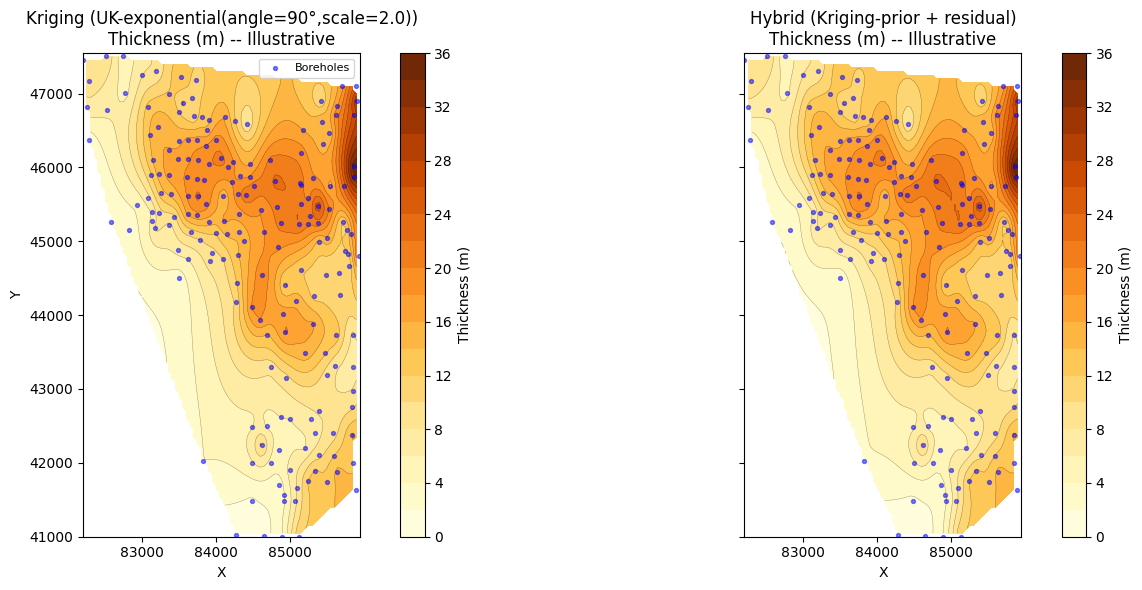

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, grid_m, title in [(axes[0], zgrid_kriging_m, f'Kriging ({KRIGING_LABEL})'),
                            (axes[1], zgrid_hybrid_m, 'Hybrid (Kriging-prior + residual)')]:
    cf = ax.contourf(gxx, gyy, grid_m, levels=20, cmap='YlOrBr')
    ax.contour(gxx, gyy, grid_m, levels=20, colors='k', linewidths=0.3, alpha=0.4)
    ax.scatter(Xf, Yf, c='blue', s=8, alpha=0.5, label='Boreholes')
    ax.set_title(f'{title}\nThickness (m) -- Illustrative')
    ax.set_xlabel('X'); ax.set_aspect('equal')
    fig.colorbar(cf, ax=ax, label='Thickness (m)')
axes[0].set_ylabel('Y'); axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'thickness_contour_maps.png'), dpi=150)
plt.show()


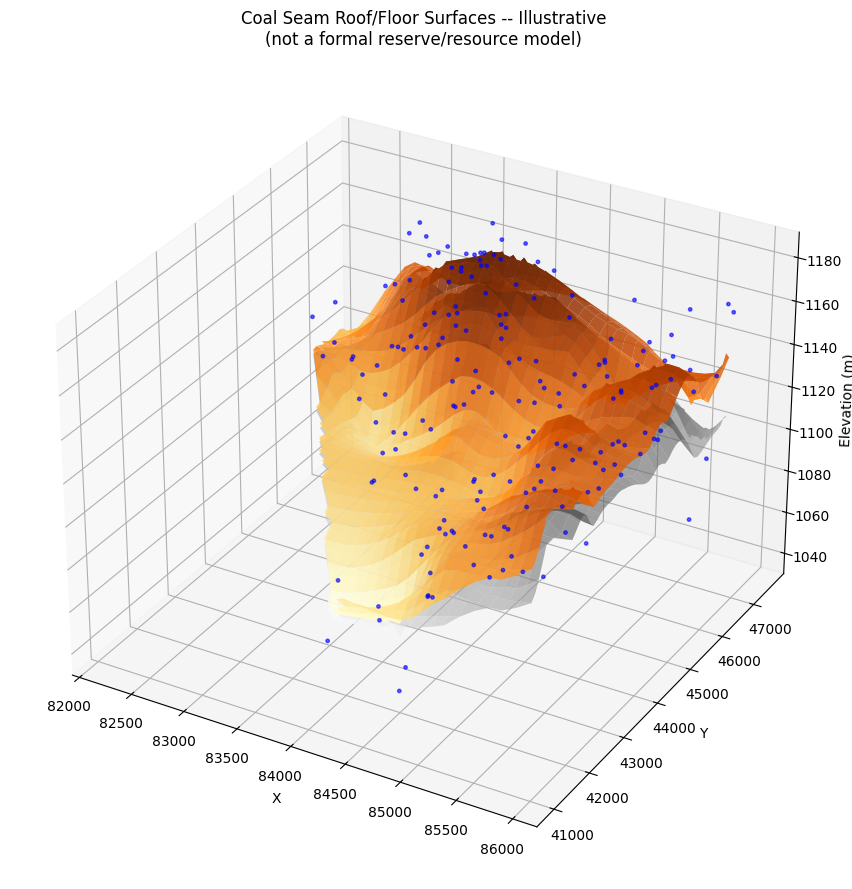

In [33]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

step = 2  # subsample for rendering performance
ax.plot_surface(gxx[::step, ::step], gyy[::step, ::step], topgrid_m[::step, ::step],
                 cmap='YlOrBr', alpha=0.85, linewidth=0, antialiased=True)
ax.plot_surface(gxx[::step, ::step], gyy[::step, ::step], bottomgrid_m[::step, ::step],
                 cmap='Greys', alpha=0.6, linewidth=0, antialiased=True)

ax.scatter(Xf, Yf, TOPf, c='blue', s=6, alpha=0.6)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Elevation (m)')
ax.set_title('Coal Seam Roof/Floor Surfaces -- Illustrative\n(not a formal reserve/resource model)')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roof_floor_3d.png'), dpi=150)
plt.show()


## 26. External validation against an independently produced DTM boundary (Micromine)

The illustrative volumetric estimate of Section 22 masks the evaluation grid to the
convex hull of the borehole coordinates. Comparison with a volumetric report
independently produced by the site operator (Micromine, from the same 191-borehole
database) revealed that this convex hull extrapolates well beyond the operator's own
drilled-footprint DTM boundary -- particularly on the western margin -- which explained
most of an initially large tonnage discrepancy. This section repeats the volumetric
integration using the operator's own DTM boundary polygon (a dense, closed drillhole-
following outline, provided as a CSV of X,Y vertices) instead of the convex hull, giving
a genuine apples-to-apples external cross-check rather than a coarse plausibility check.


In [34]:
import pandas as pd
from matplotlib.path import Path as MplPath

_MM_VOL_PATH = os.path.join(RESULTS_DIR, 'micromine_boundary_volume.json')
_MM_MASK_PATH = os.path.join(RESULTS_DIR, 'mask_mm.npy')

if os.path.exists(_MM_VOL_PATH) and os.path.exists(_MM_MASK_PATH):
    _mm = load_json(_MM_VOL_PATH, None)
    mask_mm = np.load(_MM_MASK_PATH)
    vol_kriging_mm, ton_kriging_mm = _mm['vol_kriging_m3'], _mm['ton_kriging_t']
    vol_hybrid_mm, ton_hybrid_mm = _mm['vol_hybrid_m3'], _mm['ton_hybrid_t']
    print("Micromine boundary volume loaded from cache (no re-upload needed).")
else:
    from google.colab import files
    # --- upload the operator-provided DTM boundary (CSV, columns X;Y[;RL], semicolon-separated) ---
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    print("File used:", fname)

    boundary = pd.read_csv(fname, sep=';')
    mm_path = MplPath(boundary[['X', 'Y']].values)
    mask_mm = mm_path.contains_points(np.c_[gxx.ravel(), gyy.ravel()]).reshape(gxx.shape)
    np.save(_MM_MASK_PATH, mask_mm)

    # --- volume/tonnage under the operator boundary, both models (same grid, same density) ---
    vol_kriging_mm = np.nansum(zgrid_kriging_m[mask_mm]) * GRID_RES * GRID_RES
    vol_hybrid_mm  = np.nansum(zgrid_hybrid_m[mask_mm]) * GRID_RES * GRID_RES
    ton_kriging_mm = vol_kriging_mm * DENSITY_T_PER_M3
    ton_hybrid_mm  = vol_hybrid_mm * DENSITY_T_PER_M3

    n_nan = np.isnan(zgrid_hybrid_m[mask_mm]).sum()
    n_total = mask_mm.sum()
    print(f"NaN cells inside boundary (edge effect): {n_nan} / {n_total}")

    save_json({
        'stage': 'micromine_boundary_volume',
        'vol_kriging_m3': float(vol_kriging_mm), 'ton_kriging_t': float(ton_kriging_mm),
        'vol_hybrid_m3': float(vol_hybrid_mm), 'ton_hybrid_t': float(ton_hybrid_mm),
        'n_nan_cells': int(n_nan), 'n_total_cells': int(n_total),
    }, _MM_VOL_PATH)

print("=" * 80)
print("VOLUME/TONNAGE UNDER THE OPERATOR-PROVIDED (MICROMINE) DTM BOUNDARY")
print("=" * 80)
print(f"Kriging ({KRIGING_LABEL}): {vol_kriging_mm:,.0f} m3 -> {ton_kriging_mm:,.0f} t")
print(f"Hybrid (medium):          {vol_hybrid_mm:,.0f} m3 -> {ton_hybrid_mm:,.0f} t")


Micromine boundary volume loaded from cache (no re-upload needed).
VOLUME/TONNAGE UNDER THE OPERATOR-PROVIDED (MICROMINE) DTM BOUNDARY
Kriging (UK-exponential(angle=90°,scale=2.0)): 136,631,956 m3 -> 177,621,543 t
Hybrid (medium):          136,732,946 m3 -> 177,752,830 t


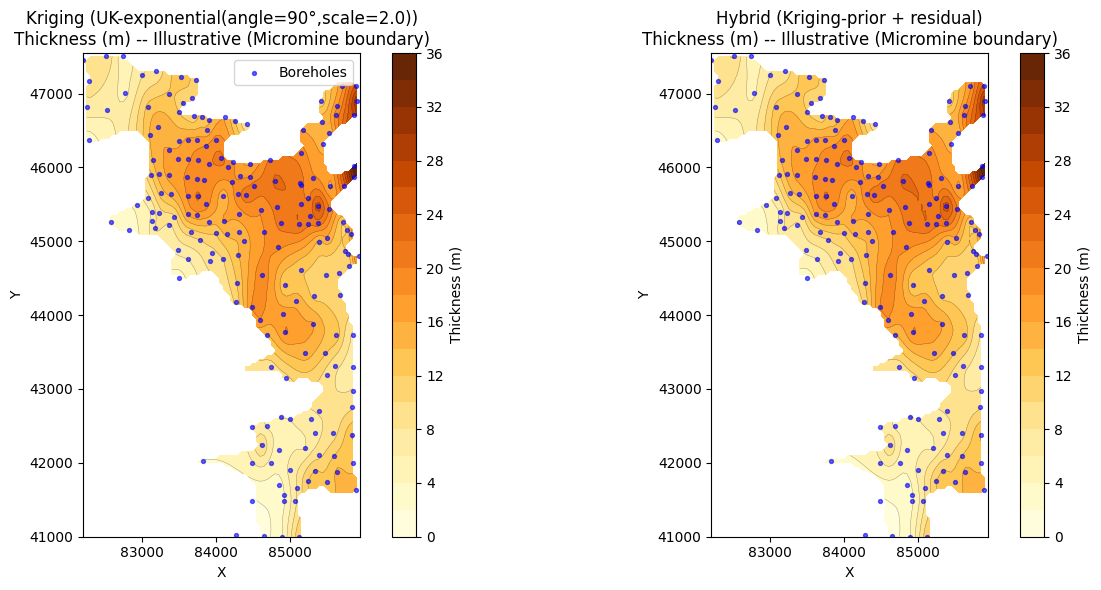

In [35]:
import numpy as np
import matplotlib.pyplot as plt

zgrid_kriging_mm = np.where(mask_mm, zgrid_kriging, np.nan)
zgrid_hybrid_mm2 = np.where(mask_mm, zgrid_hybrid, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
vmax = np.nanmax([zgrid_kriging_mm, zgrid_hybrid_mm2])

for ax, grid, title in [(axes[0], zgrid_kriging_mm, f'Kriging ({KRIGING_LABEL})'),
                          (axes[1], zgrid_hybrid_mm2, 'Hybrid (Kriging-prior + residual)')]:
    cf = ax.contourf(gxx, gyy, grid, levels=20, cmap='YlOrBr', vmin=0, vmax=vmax)
    ax.contour(gxx, gyy, grid, levels=20, colors='k', linewidths=0.3, alpha=0.4)
    ax.scatter(Xf, Yf, c='blue', s=8, alpha=0.6, label='Boreholes' if ax is axes[0] else None)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_aspect('equal')
    ax.set_title(f'{title}\nThickness (m) -- Illustrative (Micromine boundary)')
    fig.colorbar(cf, ax=ax, label='Thickness (m)')
axes[0].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'thickness_contour_maps_micromine.png'), dpi=200, bbox_inches='tight')
plt.show()

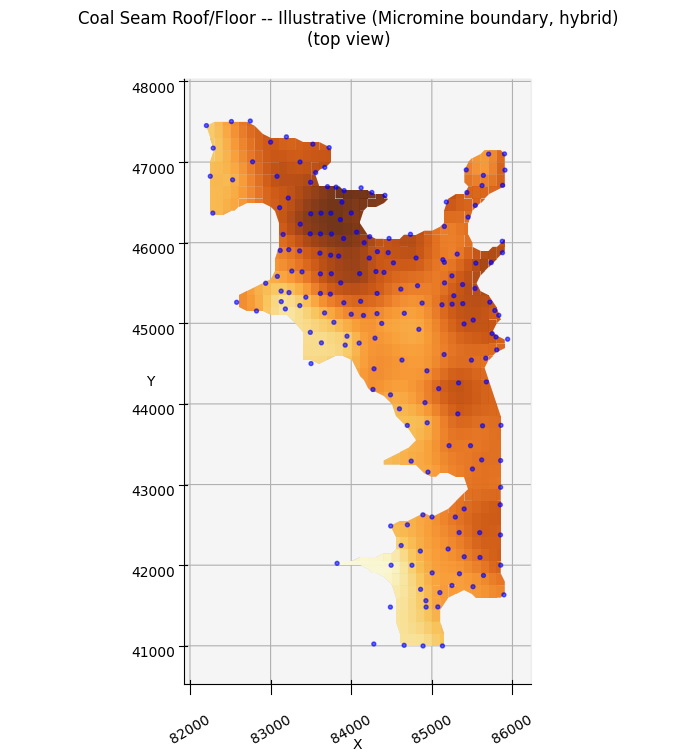

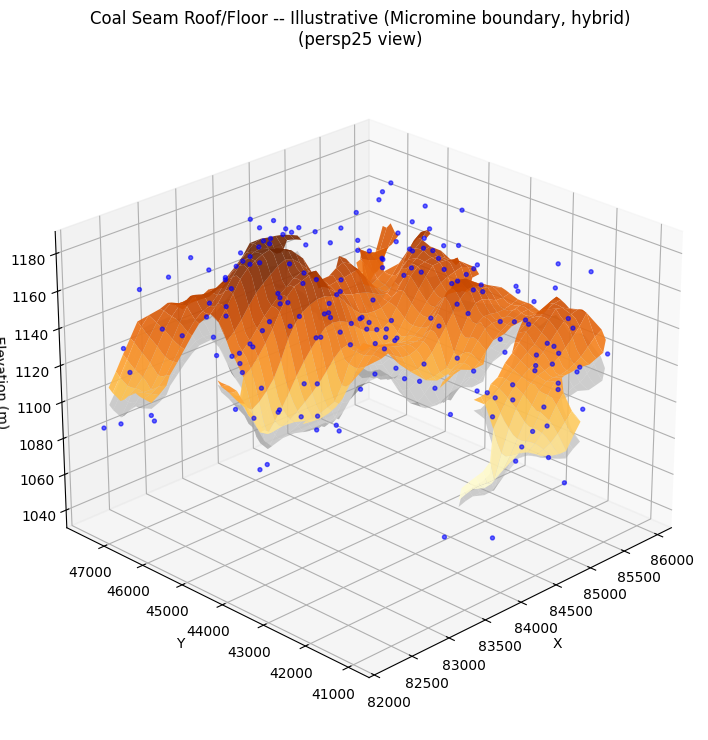

In [36]:
# --- roof/floor surfaces under the operator boundary, hybrid thickness, two viewing angles ---
topgrid_mm           = np.where(mask_mm, topgrid, np.nan)
bottomgrid_hybrid_mm = np.where(mask_mm, topgrid - zgrid_hybrid, np.nan)

for view_name, elev, azim in [('top', 90, -90), ('persp25', 25, 225)]:
    fig = plt.figure(figsize=(9, 7.5))
    ax = fig.add_subplot(111, projection='3d')
    step = 1 if view_name == 'top' else 2  # finer detail needed for the top-down view
    ax.plot_surface(gxx[::step, ::step], gyy[::step, ::step], topgrid_mm[::step, ::step],
                     cmap='YlOrBr', alpha=0.9, linewidth=0, antialiased=True)
    ax.plot_surface(gxx[::step, ::step], gyy[::step, ::step], bottomgrid_hybrid_mm[::step, ::step],
                     color='lightgray', alpha=0.5, linewidth=0, antialiased=True)
    ax.scatter(Xf, Yf, TOPf, c='blue', s=8, alpha=0.6)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Elevation (m)')
    ax.set_title(f'Coal Seam Roof/Floor -- Illustrative (Micromine boundary, hybrid)\n({view_name} view)')
    ax.view_init(elev=elev, azim=azim)

    if view_name == 'top':
        ax.set_box_aspect((gx.max() - gx.min(), gy.max() - gy.min(), 1))  # match data X:Y aspect
        ax.set_zlabel('')
        ax.set_zticks([])
        ax.set_xticks(np.arange(82000, 86001, 1000))
        ax.tick_params(axis='x', labelrotation=30)
        ax.tick_params(axis='y', pad=15)  # push Y tick labels clear of the frame
    # persp25: no aspect/zlabel override -- matplotlib's default framing reads best here

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'roof_floor_3d_micromine_{view_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()


## 23. Final discussion table: the three variogram models + all models together

This is the table that can go directly into the manuscript's "Discussion" section --
summarizing everything at a single glance.


In [37]:
_vg_raw = pd.read_csv(os.path.join(RESULTS_DIR, 'kriging_variogram_raw_comparison.csv'), index_col=0)
print("="*80)
print("STAGE 1: Variogram Model Comparison (isotropic OK)")
print("="*80)
display(_vg_raw.round(4))

_stage2_raw = pd.read_csv(os.path.join(RESULTS_DIR, 'kriging_stage2_trend_comparison.csv'), index_col=0)
print("\n" + "="*80)
print(f"STAGE 2: Trend Comparison (model='{best_vm}' fixed)")
print("="*80)
display(_stage2_raw.round(4))

_stage3_raw = pd.read_csv(os.path.join(RESULTS_DIR, 'kriging_stage3_anisotropy_grid.csv'))
print("\n" + "="*80)
print(f"STAGE 3: Anisotropy Grid (model='{best_vm}', trend='{best_drift_key}' fixed)")
print("="*80)
display(_stage3_raw.round(4))

# Final (full-data) model's variogram parameters -- nugget/partial-sill/range
_psill, _range, _nugget = uk_full.variogram_model_parameters
_total_sill = _psill + _nugget
print("\n" + "="*80)
print(f"FINAL VARIOGRAM PARAMETERS ({KRIGING_LABEL}, full-data fit)")
print("="*80)
print(f"Model: {KRIGING_CONFIG['variogram_model']} | Trend: {best_drift_key} | "
      f"Anisotropy: angle={best_angle}°, scale={best_scaling}")
print(f"Nugget: {_nugget:.4f}")
print(f"Partial sill: {_psill:.4f}")
print(f"Toplam sill: {_total_sill:.4f}")
print(f"Menzil (range): {_range:.1f} m")
print(f"Nugget/Sill ratio: {_nugget/_total_sill:.4f}")

save_json({
    'stage': 'final_variogram_parameters', 'model': KRIGING_CONFIG['variogram_model'],
    'trend': best_drift_key, 'anisotropy_angle': best_angle, 'anisotropy_scaling': best_scaling,
    'nugget': float(_nugget), 'partial_sill': float(_psill), 'total_sill': float(_total_sill),
    'range_m': float(_range), 'nugget_sill_ratio': float(_nugget/_total_sill),
}, os.path.join(RESULTS_DIR, 'final_variogram_parameters.json'))

print(f"\nSelected final Kriging reference (after all stages): {KRIGING_LABEL}")

print()
print("="*80)
print("FINAL SUMMARY OF ALL MODELS")
print("="*80)
display(summary_all.round(4))

print()
print(f"Illustrative volume/tonnage (Kriging): {ton_kriging:,.0f} t")
print(f"Illustrative volume/tonnage (Hybrid):  {ton_hybrid:,.0f} t")
print(f"(Micromine DTM report reference: ~255,529,171 t -- cross-check)")


STAGE 1: Variogram Model Comparison (isotropic OK)


,RMSE,MAE,R2,Pearson
variogram_model,,,,
spherical,6.3281,4.7438,0.3879,0.6229
exponential,6.2798,4.6998,0.3972,0.6308
gaussian,6.3709,4.7863,0.3796,0.6165



STAGE 2: Trend Comparison (model='exponential' fixed)


,RMSE,MAE,R2,Pearson
trend,,,,
OK,6.2798,4.6998,0.3972,0.6308
UK_regional_linear,6.2397,4.6937,0.4049,0.6384



STAGE 3: Anisotropy Grid (model='exponential', trend='UK_regional_linear' fixed)


,angle,scaling,RMSE,MAE,R2,Pearson
0,0,1.0,6.2397,4.6937,0.4049,0.6384
1,0,2.0,6.4916,4.8451,0.3559,0.6088
2,0,3.0,6.7507,5.0031,0.3034,0.5756
3,0,4.0,6.6195,4.9664,0.3302,0.5775
4,45,1.0,6.2397,4.6937,0.4049,0.6384
5,45,2.0,6.5920,4.9274,0.3358,0.6018
6,45,3.0,6.7680,5.0726,0.2999,0.5732
7,45,4.0,6.8223,5.1472,0.2886,0.5625
8,90,1.0,6.2397,4.6937,0.4049,0.6384
9,90,2.0,6.1746,4.7291,0.4173,0.6468



FINAL VARIOGRAM PARAMETERS (UK-exponential(angle=90°,scale=2.0), full-data fit)
Model: exponential | Trend: UK_regional_linear | Anisotropy: angle=90°, scale=2.0
Nugget: 19.1526
Partial sill: 52.1023
Toplam sill: 71.2548
Menzil (range): 3821.9 m
Nugget/Sill ratio: 0.2688

Selected final Kriging reference (after all stages): UK-exponential(angle=90°,scale=2.0)

FINAL SUMMARY OF ALL MODELS


,Model,R2,RMSE,p (vs Kriging)
0,"Kriging (UK-exponential(angle=90°,scale=2.0))",0.4173,6.1746,-
1,"PINN (large, standalone, improved)",0.3847,6.3445,0.2431
2,Hybrid (medium),0.4160,6.1812,0.9437
3,Hybrid (large),0.4167,6.1775,0.5025



Illustrative volume/tonnage (Kriging): 257,961,699 t
Illustrative volume/tonnage (Hybrid):  257,543,288 t
(Micromine DTM report reference: ~255,529,171 t -- cross-check)


## 24. Uncertainty calibration of the hybrid model

The standalone PINN's uncertainty estimate was poorly calibrated (Section 10: coverage
~11%). But this test was never repeated for the final hybrid (Kriging-prior + residual) --
a gap a reviewer will ask about. Here, we use the hybrid's own seed-to-seed (6-seed)
ensemble spread as an uncertainty proxy and place it side by side with Kriging and the
standalone PINN using the same `calibration_report` function. No extra computation -- it
is derived directly from the `hybrid_ckpt` predictions we already have.


UNCERTAINTY CALIBRATION OF ALL METHODS -- SIDE BY SIDE
(Note: 'Standalone PINN (old, Section 10)' is from the lr=1e-4/epoch=2000 configuration;
 the other three are from the lr=1e-3/epoch=1000 improved configuration -- do not mix them.)


,"spearman(std, |error|)",spearman_p,nominal_95pct_coverage
method,,,
"UK-exponential(angle=90°,scale=2.0)",-0.0670,0.35682,0.9215
PINN ensemble (large),0.0416,0.56801,0.1099
"Standalone PINN, improved (6 seeds)",0.1671,0.02089,0.1623
"Hybrid (medium, 6 seeds)",-0.0226,0.75652,0.0262
"Hybrid (large, 6 seeds)",0.1390,0.05514,0.0890



Interpretation: if spearman(std, |error|) is high and significant (p<0.05), the method
gives a reliable answer to 'where am I uncertain'. If coverage is close to 0.95,
the confidence intervals are well calibrated.


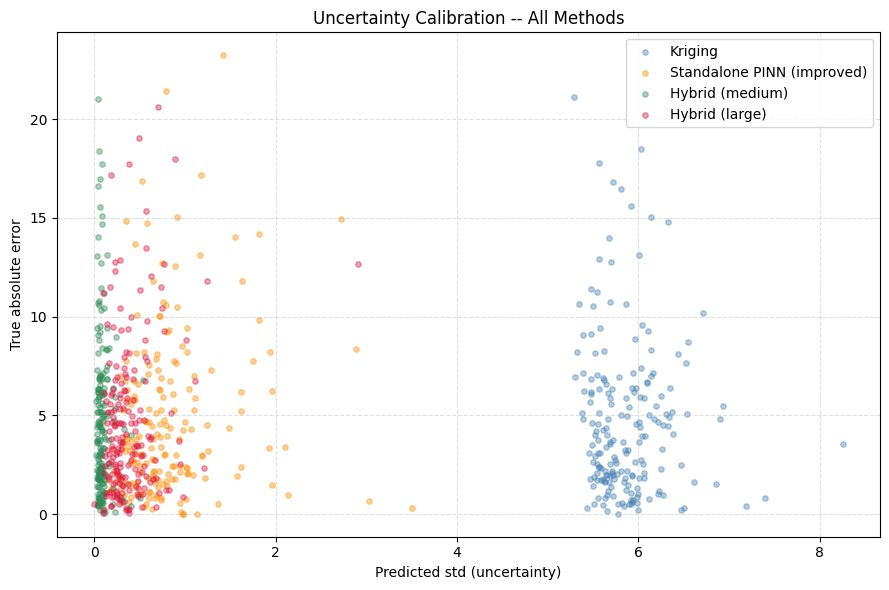

In [38]:
def std_from_checkpoint(ckpt, prefix, seeds):
    keys = [f"{prefix}__{s}" for s in seeds if f"{prefix}__{s}" in ckpt]
    arr = np.array([ckpt[k]['preds'] for k in keys])
    return arr.mean(axis=0), arr.std(axis=0), len(keys)

# IMPORTANT: preds_pinn_improved (Section 18) comes from the lr=1e-3/epoch=1000 (nihai_ckpt)
# configuration -- while std_pinn_ensemble (Section 9) comes from the OLD (lr=1e-4/epoch=2000) one.
# To avoid mixing the two, we also derive the standalone PINN's std from the SAME (improved) source.
preds_pinn_improved_c, std_pinn_improved, n_pi = std_from_checkpoint(nihai_ckpt, 'nihai_orig', HPARAM_TEST_SEEDS)
assert np.allclose(preds_pinn_improved_c, preds_pinn_improved), "preds_pinn_improved is inconsistent!"

preds_hybrid_medium_c, std_hybrid_medium, n_hm = std_from_checkpoint(hybrid_ckpt, 'medium', HPARAM_TEST_SEEDS)
preds_hybrid_large_c, std_hybrid_large, n_hl = std_from_checkpoint(hybrid_ckpt, 'large', HPARAM_TEST_SEEDS)

calib_pinn_improved = calibration_report(y_true_eval, preds_pinn_improved, std_pinn_improved,
                                          f'Standalone PINN, improved ({n_pi} seeds)')
calib_hybrid_medium = calibration_report(y_true_eval, preds_hybrid_medium_c, std_hybrid_medium,
                                          f'Hybrid (medium, {n_hm} seeds)')
calib_hybrid_large = calibration_report(y_true_eval, preds_hybrid_large_c, std_hybrid_large,
                                         f'Hybrid (large, {n_hl} seeds)')

print("="*80)
print("UNCERTAINTY CALIBRATION OF ALL METHODS -- SIDE BY SIDE")
print("="*80)
print("(Note: 'Standalone PINN (old, Section 10)' is from the lr=1e-4/epoch=2000 configuration;")
print(" the other three are from the lr=1e-3/epoch=1000 improved configuration -- do not mix them.)")
calibration_table_full = pd.DataFrame([
    calib_kriging, calib_pinn, calib_pinn_improved, calib_hybrid_medium, calib_hybrid_large
]).set_index('method')
display(calibration_table_full)

print("\nInterpretation: if spearman(std, |error|) is high and significant (p<0.05), the method")
print("gives a reliable answer to 'where am I uncertain'. If coverage is close to 0.95,")
print("the confidence intervals are well calibrated.")

calibration_table_full.to_csv(os.path.join(RESULTS_DIR, 'uncertainty_calibration_full.csv'))

fig, ax = plt.subplots(figsize=(9, 6))
for std_arr, preds_arr, label, color in [
    (std_kriging, preds_kriging, 'Kriging', 'steelblue'),
    (std_pinn_improved, preds_pinn_improved, 'Standalone PINN (improved)', 'darkorange'),
    (std_hybrid_medium, preds_hybrid_medium_c, 'Hybrid (medium)', 'seagreen'),
    (std_hybrid_large, preds_hybrid_large_c, 'Hybrid (large)', 'crimson'),
]:
    ax.scatter(std_arr, np.abs(y_true_eval - preds_arr), alpha=0.4, s=15, label=label, color=color)
ax.set_xlabel('Predicted std (uncertainty)')
ax.set_ylabel('True absolute error')
ax.set_title('Uncertainty Calibration -- All Methods')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'uncertainty_calibration_full.png'), dpi=150)
plt.show()


## 25. An alternative uncertainty source for the hybrid: Kriging variance instead of seed spread

Section 24's finding: the hybrid's seed-to-seed ensemble spread does not inherit Kriging's
training-time variance -- coverage came out poorly, 2.6-8.9%. The reason is conceptual:
seed spread measures optimization variance, not geostatistical prediction uncertainty.

Here, we re-measure calibration by pairing the hybrid's mean prediction
(`preds_hybrid_medium_c`, `preds_hybrid_large_c` -- already from Section 24) directly with
**Kriging's own variance** (`std_kriging`, from Section 5, no extra computation) -- the
logic: since the hybrid's mean is already Kriging plus a small correction, Kriging's
variance may also be a reasonable proxy for it.


In [39]:
calib_hybrid_medium_kstd = calibration_report(
    y_true_eval, preds_hybrid_medium_c, std_kriging, 'Hybrid (medium), Kriging variance')
calib_hybrid_large_kstd = calibration_report(
    y_true_eval, preds_hybrid_large_c, std_kriging, 'Hybrid (large), Kriging variance')

print("="*80)
print("HYBRID CALIBRATION: seed-spread (Section 24) vs. Kriging variance (this section)")
print("="*80)
calibration_table_v2 = pd.DataFrame([
    calib_kriging, calib_hybrid_medium, calib_hybrid_medium_kstd,
    calib_hybrid_large, calib_hybrid_large_kstd,
]).set_index('method')
display(calibration_table_v2)

print("\nInterpretation: if the coverage in the Kriging-variance rows is closer to 0.95,")
print("using Kriging variance instead of seed-spread as the hybrid's uncertainty source")
print("is recommended -- this can be reported in the manuscript as the better-calibrated result.")

calibration_table_v2.to_csv(os.path.join(RESULTS_DIR, 'uncertainty_calibration_hybrid_kstd.csv'))


HYBRID CALIBRATION: seed-spread (Section 24) vs. Kriging variance (this section)


,"spearman(std, |error|)",spearman_p,nominal_95pct_coverage
method,,,
"UK-exponential(angle=90°,scale=2.0)",-0.0670,0.35682,0.9215
"Hybrid (medium, 6 seeds)",-0.0226,0.75652,0.0262
"Hybrid (medium), Kriging variance",-0.0731,0.31483,0.9215
"Hybrid (large, 6 seeds)",0.1390,0.05514,0.0890
"Hybrid (large), Kriging variance",-0.0481,0.50901,0.9215



Interpretation: if the coverage in the Kriging-variance rows is closer to 0.95,
using Kriging variance instead of seed-spread as the hybrid's uncertainty source
is recommended -- this can be reported in the manuscript as the better-calibrated result.
